# Notebook 3: Model Training and Comparison

This notebook trains and evaluates all five models in the dissertation's comparative study:

1. **Logistic Regression** — transparent linear baseline
2. **MLP** — non-linear feed-forward network, same tabular features
3. **XGBoost** — gradient-boosted trees, captures feature interactions
4. **LSTM** — sequence model exploiting temporal structure
5. **Transformer** — attention-based sequence model

All models are trained on the same chronological splits, evaluated with the same metrics, and compared in a single results table.

## Objective

- Establish a rigorous, reproducible performance comparison across model families on **two prediction tasks**.
- **Task 1 — Classification**: predict the binary direction of SPY's next-day move (Up / Down). Primary metric: **balanced accuracy** (avoids class-imbalance inflation); secondary: **ROC-AUC**.
- **Task 2 — Regression**: predict SPY's next-day percentage return (continuous). Primary metric: **RMSE**; secondary: **MAE** and **R²**.
- Evaluate both tasks under identical strict chronological splits — no random shuffling at any stage.
- All five model families (Logistic/Ridge, MLP, XGBoost, LSTM, Transformer) are trained on both tasks, enabling a direct comparison of model rankings across the two problem types.

In [ ]:
import warnings
import random
import sys
import time
from pathlib import Path
from typing import List, Optional, Tuple

import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

# sklearn
from sklearn.calibration import calibration_curve
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_recall_curve,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

# statsmodels (for McNemar's test in Section 7)
from statsmodels.stats.contingency_tables import mcnemar

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    try:
        plt.style.use("seaborn-whitegrid")
    except OSError:
        plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["figure.dpi"] = 140

: 

In [ ]:
def find_project_root(marker="config.py"):
    p = Path.cwd().resolve()
    for _ in range(6):
        if (p / marker).exists():
            return p
        p = p.parent
    raise FileNotFoundError(f"Cannot locate {marker} above {Path.cwd()}")

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from config import (                        # noqa: E402
    FEATURE_DATA_DIR, MODEL_DIR,
    TARGET_SYMBOL, AUXILIARY_SYMBOLS, AUXILIARY_FEATURES,
    TRAIN_END_DATE, VAL_END_DATE,
)

In [ ]:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Compute device: {DEVICE}")

# ── Column names ──────────────────────────────────────────────────────────
DATE_COLUMN        = "date"
SYMBOL_COLUMN      = "symbol"
# TARGET_SYMBOL, AUXILIARY_SYMBOLS, AUXILIARY_FEATURES imported from config.py
TARGET_COLUMN      = "target_direction"         # classification target
REGRESSION_TARGET  = "target_next_return"       # regression target (stationary; next-day close = close*(1+return))
ALL_TARGET_COLUMNS = ["target_next_close", "target_next_return", "target_direction"]
METADATA_COLUMNS   = [DATE_COLUMN, SYMBOL_COLUMN]

FEATURE_FILE_CANDIDATES = [
    FEATURE_DATA_DIR / "equity_daily_features.parquet",
    FEATURE_DATA_DIR / "equity_daily_features.csv",
]

# ── Chronological split anchors (imported from config.py as strings) ──────
# Convert to Timestamps at point of use.
TRAIN_END_DATE = pd.Timestamp(TRAIN_END_DATE)
VAL_END_DATE   = pd.Timestamp(VAL_END_DATE)
TEST_END_DATE  = None          # uses full data up to the latest available date

# ── Auxiliary context (same-day features from correlated assets) ──────────
# AUXILIARY_SYMBOLS and AUXILIARY_FEATURES imported from config.py
USE_AUXILIARY_CONTEXT = True
EXCLUDE_FEATURES      = []

# ── Sequence hyperparameters (LSTM / Transformer) ─────────────────────────
SEQ_LEN = 20        # lookback window in trading days (~1 calendar month)

# ── LSTM ──────────────────────────────────────────────────────────────────
LSTM_HIDDEN_DIM  = 32
LSTM_NUM_LAYERS  = 1
LSTM_DROPOUT     = 0.5

# ── Transformer ───────────────────────────────────────────────────────────
TF_D_MODEL    = 32   # must be divisible by TF_NHEAD
TF_NHEAD      = 2
TF_NUM_LAYERS = 1
TF_DIM_FF     = 64
TF_DROPOUT    = 0.5

# ── Shared training hyperparameters (LSTM + Transformer) ─────────────────
BATCH_SIZE   = 64
MAX_EPOCHS   = 100
LR           = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE     = 15
LR_PATIENCE  = 7
LR_FACTOR    = 0.5
GRAD_CLIP    = 1.0

# ── Output directories ────────────────────────────────────────────────────
RESULTS_DIR         = PROJECT_ROOT / "results"
TABLES_DIR          = RESULTS_DIR / "tables"
FIGURES_DIR         = RESULTS_DIR / "figures" / "model_comparison"
MODEL_ARTIFACTS_DIR = MODEL_DIR / "trained"
SAVE_MODEL_ARTIFACTS = True

for _d in [RESULTS_DIR, TABLES_DIR, FIGURES_DIR, MODEL_ARTIFACTS_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

print(f"Project root : {PROJECT_ROOT}")
print(f"Figures dir  : {FIGURES_DIR}")
print(f"Artefacts dir: {MODEL_ARTIFACTS_DIR}")

Compute device: cuda
Project root : C:\Users\clara\OneDrive\Documents\DissWork
Figures dir  : C:\Users\clara\OneDrive\Documents\DissWork\results\figures\model_comparison
Artefacts dir: C:\Users\clara\OneDrive\Documents\DissWork\models\trained


## Data Loading

The engineered feature dataset produced by Notebook 2 is loaded. Both Parquet and CSV are supported.

In [ ]:
def load_feature_dataset(candidates: List[Path]) -> Tuple[pd.DataFrame, Path]:
    for path in candidates:
        if path.exists():
            ext = path.suffix.lower()
            df  = pd.read_parquet(path) if ext == ".parquet" else pd.read_csv(path, parse_dates=[DATE_COLUMN])
            return df, path
    raise FileNotFoundError(
        "No feature dataset found. Run Notebook 2 first. Expected one of: "
        + ", ".join(str(p) for p in candidates)
    )


raw_df, feature_path = load_feature_dataset(FEATURE_FILE_CANDIDATES)
print(f"Loaded: {feature_path}")
print(f"Shape : {raw_df.shape}")

required = set(METADATA_COLUMNS + ALL_TARGET_COLUMNS)
missing  = required.difference(raw_df.columns)
if missing:
    raise ValueError(f"Missing required columns: {sorted(missing)}")

if not pd.api.types.is_datetime64_any_dtype(raw_df[DATE_COLUMN]):
    raw_df[DATE_COLUMN] = pd.to_datetime(raw_df[DATE_COLUMN], errors="coerce")

raw_df = raw_df.sort_values([SYMBOL_COLUMN, DATE_COLUMN]).reset_index(drop=True)

Loaded: C:\Users\clara\OneDrive\Documents\DissWork\data\features\equity_daily_features.csv
Shape : (69050, 59)


## SPY Modelling Dataset

The target asset is **SPY** throughout. Optional same-day contextual features from correlated assets (QQQ, IWM, AAPL, EEM, USO) are merged on date to give the model cross-asset information.

In [ ]:
def build_target_asset_dataset(
    df: pd.DataFrame,
    target_symbol: str,
    use_auxiliary_context: bool = False,
    auxiliary_symbols: Optional[List[str]] = None,
    auxiliary_features: Optional[List[str]] = None,
) -> Tuple[pd.DataFrame, List[str], List[str]]:
    if target_symbol not in df[SYMBOL_COLUMN].unique():
        raise ValueError(f"'{target_symbol}' not found in dataset.")

    target_df = (
        df.loc[df[SYMBOL_COLUMN] == target_symbol]
        .copy().sort_values(DATE_COLUMN).reset_index(drop=True)
    )
    if target_df.duplicated(subset=[DATE_COLUMN]).any():
        raise ValueError(f"Duplicate dates found for '{target_symbol}'.")

    base_features = [
        c for c in target_df.columns
        if c not in METADATA_COLUMNS + ALL_TARGET_COLUMNS + EXCLUDE_FEATURES
    ]
    aux_cols: List[str] = []

    if use_auxiliary_context:
        auxiliary_symbols = auxiliary_symbols or []
        auxiliary_features = auxiliary_features or []
        available = set(df[SYMBOL_COLUMN].unique())
        selected  = [s for s in auxiliary_symbols if s in available and s != target_symbol]
        if selected and auxiliary_features:
            aux_df   = df.loc[df[SYMBOL_COLUMN].isin(selected),
                               [DATE_COLUMN, SYMBOL_COLUMN, *auxiliary_features]].copy()
            aux_wide = aux_df.pivot_table(
                index=DATE_COLUMN, columns=SYMBOL_COLUMN,
                values=auxiliary_features, aggfunc="last",
            )
            aux_wide.columns = [f"{s}_{f}" for f, s in aux_wide.columns.to_flat_index()]
            target_df = target_df.merge(aux_wide.reset_index(), on=DATE_COLUMN, how="left")
            aux_cols  = [c for c in target_df.columns
                         if c not in METADATA_COLUMNS + ALL_TARGET_COLUMNS + base_features]

    target_df = target_df.loc[target_df[TARGET_COLUMN].notna()].copy()
    target_df[TARGET_COLUMN] = target_df[TARGET_COLUMN].astype(int)
    return target_df, base_features + aux_cols, aux_cols


model_df, feature_columns, auxiliary_columns = build_target_asset_dataset(
    raw_df, TARGET_SYMBOL, USE_AUXILIARY_CONTEXT, AUXILIARY_SYMBOLS, AUXILIARY_FEATURES,
)
print(f"SPY dataset : {model_df.shape}")
print(f"Features    : {len(feature_columns)}  (auxiliary: {len(auxiliary_columns)})")
print(f"Date range  : {model_df[DATE_COLUMN].min().date()} \u2192 {model_df[DATE_COLUMN].max().date()}")

# ── Feature column sanity check ───────────────────────────────────────────
print(f"\nFeature columns: {len(feature_columns)}")
print(f"Sample: {feature_columns[:5]} ... {feature_columns[-5:]}")

leaky = [c for c in feature_columns if "target" in c.lower() or "next" in c.lower()]
if leaky:
    raise ValueError(f"Potential target leakage in features: {leaky}")
meta_leak = [c for c in feature_columns if c in METADATA_COLUMNS]
if meta_leak:
    raise ValueError(f"Metadata columns in features: {meta_leak}")
print("Feature check passed: no target leakage, no metadata columns.")

SPY dataset : (5799, 74)
Features    : 69  (auxiliary: 15)
Date range  : 1998-03-16 → 2021-03-30

Feature columns: 69
Sample: ['open', 'high', 'low', 'close', 'volume'] ... ['AAPL_volume_change', 'EEM_volume_change', 'IWM_volume_change', 'QQQ_volume_change', 'USO_volume_change']
Feature check passed: no target leakage, no metadata columns.


## Chronological Splits

The dataset is divided into non-overlapping train, validation, and test windows. No data from the validation or test period is ever used during training or preprocessing — this is the core protection against look-ahead bias in financial time-series modelling.

In [ ]:
def make_time_splits(
    df: pd.DataFrame,
    train_end: pd.Timestamp,
    val_end: pd.Timestamp,
    test_end: Optional[pd.Timestamp] = None,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    test_end  = test_end or df[DATE_COLUMN].max()
    train_df  = df.loc[df[DATE_COLUMN] <= train_end].copy()
    val_df    = df.loc[(df[DATE_COLUMN] > train_end) & (df[DATE_COLUMN] <= val_end)].copy()
    test_df   = df.loc[(df[DATE_COLUMN] > val_end)   & (df[DATE_COLUMN] <= test_end)].copy()
    if train_df.empty or val_df.empty or test_df.empty:
        raise ValueError("One or more splits are empty — check split dates.")
    return train_df, val_df, test_df


train_df, val_df, test_df = make_time_splits(
    model_df, TRAIN_END_DATE, VAL_END_DATE, TEST_END_DATE,
)

split_summary = pd.DataFrame([
    {"split": "train",      "rows": len(train_df),
     "start": train_df[DATE_COLUMN].min().date(), "end": train_df[DATE_COLUMN].max().date(),
     "positive_rate": round(train_df[TARGET_COLUMN].mean(), 4)},
    {"split": "validation", "rows": len(val_df),
     "start": val_df[DATE_COLUMN].min().date(),   "end": val_df[DATE_COLUMN].max().date(),
     "positive_rate": round(val_df[TARGET_COLUMN].mean(), 4)},
    {"split": "test",       "rows": len(test_df),
     "start": test_df[DATE_COLUMN].min().date(),  "end": test_df[DATE_COLUMN].max().date(),
     "positive_rate": round(test_df[TARGET_COLUMN].mean(), 4)},
])
display(split_summary)
split_summary.to_csv(TABLES_DIR / "split_summary.csv", index=False)

X_train = train_df[feature_columns]
y_train = train_df[TARGET_COLUMN]
X_val   = val_df[feature_columns]
y_val   = val_df[TARGET_COLUMN]
X_test  = test_df[feature_columns]
y_test  = test_df[TARGET_COLUMN]

,split,rows,start,end,positive_rate
0,train,4732,1998-03-16,2016-12-30,0.5260
1,validation,502,2017-01-03,2018-12-31,0.5438
2,test,565,2019-01-02,2021-03-30,0.5805


## Evaluation Framework

All five models share the same metric set and helper functions, ensuring results are directly comparable.

In [ ]:
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    TREE_MODEL_LABEL  = "XGBoost"
except ImportError:
    XGBOOST_AVAILABLE = False
    TREE_MODEL_LABEL  = "Random Forest"

print(f"Tree model: {TREE_MODEL_LABEL}")


def get_scores(y_true, y_pred, y_score=None) -> dict:
    return {
        "accuracy":          accuracy_score(y_true, y_pred),
        "precision":         precision_score(y_true, y_pred, zero_division=0),
        "recall":            recall_score(y_true, y_pred, zero_division=0),
        "f1":                f1_score(y_true, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "roc_auc":           roc_auc_score(y_true, y_score)
                             if y_score is not None and len(np.unique(y_true)) == 2
                             else float("nan"),
    }


def flat_row(name: str, notes: str, val_m: dict, test_m: dict) -> dict:
    row = {"model": name, "notes": notes}
    for pfx, m in [("validation", val_m), ("test", test_m)]:
        for k, v in m.items():
            row[f"{pfx}_{k}"] = v
    return row


all_results: List[dict] = []

Tree model: XGBoost


## Naive Benchmarks

Two trivial predictors establish the performance floor.

**Majority Class** — predicts the most common label ("Up", ~53% of training days) every day unconditionally. Any real model must beat this on *balanced accuracy* — a model that cannot is simply learning the class distribution.

**Persistence** — predicts that tomorrow will repeat today's direction (positive return → predict Up). Tests whether first-order return autocorrelation is exploitable at a daily frequency.

In [ ]:
# ── Majority Class ────────────────────────────────────────────────────────
majority = DummyClassifier(strategy="most_frequent")
majority.fit(np.zeros((len(y_train), 1)), y_train)

maj_vp = majority.predict(np.zeros((len(y_val),  1)))
maj_tp = majority.predict(np.zeros((len(y_test), 1)))

all_results.append(flat_row(
    "Majority Class",
    "Always predicts the most frequent class in the training set.",
    get_scores(y_val,  maj_vp),
    get_scores(y_test, maj_tp),
))

# ── Persistence ───────────────────────────────────────────────────────────
per_vp = (val_df["return_1d"]  > 0).astype(int).to_numpy()
per_tp = (test_df["return_1d"] > 0).astype(int).to_numpy()

all_results.append(flat_row(
    "Persistence",
    "Predicts tomorrow's direction matches today's sign of return.",
    get_scores(y_val,  per_vp),
    get_scores(y_test, per_tp),
))

print("Naive benchmarks done.")

Naive benchmarks done.


## 1 — Logistic Regression

A transparent linear classifier. Preprocessing (median imputation + standardisation) is fitted on the training set only.

In [ ]:
lr_model = Pipeline([
    ("imputer",    SimpleImputer(strategy="median")),
    ("scaler",     StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000, solver="lbfgs",
        class_weight="balanced", random_state=RANDOM_SEED,
    )),
])
lr_model.fit(X_train, y_train)

lr_vp = lr_model.predict(X_val);   lr_vs = lr_model.predict_proba(X_val)[:, 1]
lr_tp = lr_model.predict(X_test);  lr_ts = lr_model.predict_proba(X_test)[:, 1]

all_results.append(flat_row(
    "Logistic Regression",
    "Linear classifier; train-only median imputation and standardisation.",
    get_scores(y_val,  lr_vp, lr_vs),
    get_scores(y_test, lr_tp, lr_ts),
))

# Top coefficients
lr_coefs = pd.Series(
    lr_model.named_steps["classifier"].coef_[0], index=feature_columns
).sort_values(key=np.abs, ascending=False)
display(lr_coefs.head(10).to_frame("coefficient").round(4))
lr_coefs.reset_index().rename(columns={"index": "feature"}).to_csv(
    TABLES_DIR / "logistic_coefficients.csv", index=False
)
print("Logistic Regression done.")

,coefficient
bb_lower_20,-0.5942
bb_upper_20,0.5281
close_over_ma_20,-0.4819
ma_50,0.3866
close,-0.3638
close_lag_3,0.3430
ma_10_over_20,0.3073
low,-0.2310
close_to_bb_upper,0.2004
high,-0.1753


Logistic Regression done.


## 2 — MLP (PyTorch)

A feed-forward neural network with two hidden layers (128 → 64 units, ReLU, dropout 0.5). Implemented in PyTorch so it shares the same training infrastructure as the LSTM and Transformer: `BCEWithLogitsLoss` with `pos_weight` class balancing, Adam optimiser, `ReduceLROnPlateau` scheduling, gradient clipping, and early stopping on validation loss.

Because `run_training`, `train_loader`, and `pos_weight` are defined in the deep-learning section below, the class definition and training happen there. The variables `mlp_tp`, `mlp_ts`, `mlp_vp`, `mlp_vs` match the tabular-model array shapes and are available for all downstream evaluation cells.

In [ ]:
# MLP Classifier (PyTorch) — defined and trained after sequence preprocessing.
# Dependencies not yet available at this position: n_features, pos_weight,
# train_loader, val_loader, run_training.  See deep-learning section below.
# Variables set there: mlp_model, mlp_history, mlp_vp, mlp_vs, mlp_tp, mlp_ts

## 3 — XGBoost

A gradient-boosted tree ensemble. XGBoost handles missing values natively (the imputer is still included for consistency) and captures non-linear feature interactions and threshold effects that linear models cannot.

In [ ]:
if XGBOOST_AVAILABLE:
    tree_clf = XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
        objective="binary:logistic", eval_metric="logloss",
        random_state=RANDOM_SEED, n_jobs=-1,
    )
else:
    tree_clf = RandomForestClassifier(
        n_estimators=500, max_depth=6, min_samples_leaf=20,
        max_features="sqrt", class_weight="balanced_subsample",
        random_state=RANDOM_SEED, n_jobs=-1,
    )

tree_model = Pipeline([
    ("imputer",    SimpleImputer(strategy="median")),
    ("classifier", tree_clf),
])
tree_model.fit(X_train, y_train)

tree_vp = tree_model.predict(X_val);   tree_vs = tree_model.predict_proba(X_val)[:, 1]
tree_tp = tree_model.predict(X_test);  tree_ts = tree_model.predict_proba(X_test)[:, 1]

all_results.append(flat_row(
    TREE_MODEL_LABEL,
    f"Gradient-boosted tree ensemble ({TREE_MODEL_LABEL}); train-only imputation.",
    get_scores(y_val,  tree_vp, tree_vs),
    get_scores(y_test, tree_tp, tree_ts),
))

# Feature importances
tree_imp = pd.Series(
    tree_model.named_steps["classifier"].feature_importances_, index=feature_columns
).sort_values(ascending=False)
display(tree_imp.head(10).to_frame("importance").round(4))
tree_imp.reset_index().rename(columns={"index": "feature"}).to_csv(
    TABLES_DIR / "tree_feature_importance.csv", index=False
)
print(f"{TREE_MODEL_LABEL} done.")

,importance
ma_5,0.0194
return_sum_10,0.0183
bb_mid_20,0.0180
bb_lower_20,0.0176
ma_20,0.0172
close_lag_1,0.0172
low,0.0172
low_close_ratio,0.0166
volume_ma_10,0.0164
high_close_ratio,0.0161


XGBoost done.


## Sequence Preprocessing (LSTM and Transformer)

For the two sequence models the feature matrix must be imputed, scaled, and reshaped into sliding windows of length `SEQ_LEN`. The imputer and scaler are fitted on the training rows only — identical to the tabular preprocessing — then applied to the full SPY array before windowing.

Each sequence ending at day *t* predicts `target_direction[t]`. The split membership of a sequence is determined by the date of its **last** timestep, so validation sequences may draw their first few context rows from the training period without any label leakage.

In [ ]:
X_all_raw = model_df[feature_columns].values.astype(np.float64)
y_all      = model_df[TARGET_COLUMN].values.astype(np.float32)
dates_all  = model_df[DATE_COLUMN].reset_index(drop=True)

train_mask = (dates_all <= TRAIN_END_DATE).values

seq_imputer = SimpleImputer(strategy="median")
seq_imputer.fit(X_all_raw[train_mask])
X_imp = seq_imputer.transform(X_all_raw)

seq_scaler = StandardScaler()
seq_scaler.fit(X_imp[train_mask])
X_scaled = seq_scaler.transform(X_imp).astype(np.float32)

# Positive-class weight for BCEWithLogitsLoss
n_pos      = int((y_all[train_mask] == 1).sum())
n_neg      = int((y_all[train_mask] == 0).sum())
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32)
print(f"Pos weight: {pos_weight.item():.4f}  (pos={n_pos}, neg={n_neg})")


class SequenceDataset(Dataset):
    def __init__(self, X, y, seq_len, valid_indices):
        self.X, self.y = X, y
        self.seq_len   = seq_len
        self.indices   = valid_indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        end = self.indices[i]
        return (torch.from_numpy(self.X[end - self.seq_len + 1 : end + 1]),
                torch.tensor(self.y[end]))


def split_indices(dates, start_cond, end_cond, seq_len):
    mask   = (start_cond & end_cond).values
    cands  = np.where(mask)[0]
    return cands[cands >= seq_len - 1]


test_end_ts = dates_all.max() if TEST_END_DATE is None else TEST_END_DATE

train_idx = split_indices(dates_all, dates_all >= dates_all.min(), dates_all <= TRAIN_END_DATE, SEQ_LEN)
val_idx   = split_indices(dates_all, dates_all > TRAIN_END_DATE,   dates_all <= VAL_END_DATE,   SEQ_LEN)
test_idx  = split_indices(dates_all, dates_all > VAL_END_DATE,     dates_all <= test_end_ts,    SEQ_LEN)

train_loader = DataLoader(SequenceDataset(X_scaled, y_all, SEQ_LEN, train_idx),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(SequenceDataset(X_scaled, y_all, SEQ_LEN, val_idx),
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(SequenceDataset(X_scaled, y_all, SEQ_LEN, test_idx),
                          batch_size=BATCH_SIZE, shuffle=False)

print(f"Sequences — train: {len(train_idx)}  val: {len(val_idx)}  test: {len(test_idx)}")

Pos weight: 0.9012  (pos=2489, neg=2243)
Sequences — train: 4713  val: 502  test: 565


## Deep Learning Architectures

Both models share the same input shape `(batch, SEQ_LEN, n_features)` and produce a single logit per sequence.

In [ ]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.classifier(self.dropout(h_n[-1])).squeeze(-1)


class TransformerClassifier(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2,
                 dim_feedforward=128, dropout=0.1, max_seq_len=100):
        super().__init__()
        self.input_proj  = nn.Linear(input_dim, d_model)
        self.pos_embed   = nn.Embedding(max_seq_len, d_model)
        enc_layer        = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True, norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.dropout     = nn.Dropout(dropout)
        self.classifier  = nn.Linear(d_model, 1)

    def forward(self, x):
        B, T, _ = x.shape
        pos = torch.arange(T, device=x.device).unsqueeze(0).expand(B, -1)
        x   = self.input_proj(x) + self.pos_embed(pos)
        x   = self.transformer(x)
        return self.classifier(self.dropout(x[:, -1, :])).squeeze(-1)


n_features  = X_scaled.shape[1]
lstm_model  = LSTMClassifier(n_features, LSTM_HIDDEN_DIM, LSTM_NUM_LAYERS, LSTM_DROPOUT).to(DEVICE)
tf_model    = TransformerClassifier(n_features, TF_D_MODEL, TF_NHEAD, TF_NUM_LAYERS,
                                    TF_DIM_FF, TF_DROPOUT, max_seq_len=SEQ_LEN + 10).to(DEVICE)

print(f"LSTM params       : {sum(p.numel() for p in lstm_model.parameters() if p.requires_grad):,}")
print(f"Transformer params: {sum(p.numel() for p in tf_model.parameters() if p.requires_grad):,}")

LSTM params       : 13,217
Transformer params: 11,777


In [ ]:
def train_one_epoch(model, loader, opt, criterion):
    model.train()
    total = 0.0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        loss = criterion(model(X), y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        opt.step()
        total += loss.item() * len(y)
    return total / len(loader.dataset)


@torch.no_grad()
def eval_loader(model, loader, criterion, apply_sigmoid=True):
    """Evaluate model on a DataLoader.

    Parameters
    ----------
    apply_sigmoid : bool
        True for classification (BCEWithLogitsLoss logits → probabilities).
        False for regression (raw predictions returned as-is).
    """
    model.eval()
    total, out_list, label_list = 0.0, [], []
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        raw = model(X)
        total += criterion(raw, y).item() * len(y)
        output = torch.sigmoid(raw).cpu().numpy() if apply_sigmoid else raw.cpu().numpy()
        out_list.append(output)
        label_list.append(y.cpu().numpy())
    return total / len(loader.dataset), np.concatenate(out_list), np.concatenate(label_list)


def run_training(model, name, train_loader, val_loader, train_criterion, val_criterion=None, task="classification"):
    """Unified training loop for classification and regression.

    Parameters
    ----------
    train_criterion : loss
        Loss used during back-propagation (e.g. BCEWithLogitsLoss with pos_weight).
    val_criterion : loss or None
        Loss used for validation book-keeping. Defaults to train_criterion when None.
        Pass plain BCEWithLogitsLoss (no pos_weight) for a neutral generalisation measure.
    task : {"classification", "regression"}
        Determines the validation metric tracked (balanced accuracy vs RMSE).
    """
    if val_criterion is None:
        val_criterion = train_criterion
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="min", factor=LR_FACTOR, patience=LR_PATIENCE,
    )
    metric_key = "val_bal_acc" if task == "classification" else "val_rmse"
    history = {"epoch": [], "train_loss": [], "val_loss": [], metric_key: []}
    best_loss, best_state, patience_ctr = float("inf"), None, 0
    t0 = time.time()

    for epoch in range(1, MAX_EPOCHS + 1):
        tr_loss = train_one_epoch(model, train_loader, opt, train_criterion)
        vl_loss, vp, vl = eval_loader(
            model, val_loader, val_criterion,
            apply_sigmoid=(task == "classification"),
        )
        scheduler.step(vl_loss)

        if task == "classification":
            metric = balanced_accuracy_score(vl, (vp >= 0.5).astype(int))
        else:
            metric = float(np.sqrt(mean_squared_error(vl, vp)))

        history["epoch"].append(epoch)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history[metric_key].append(metric)

        if vl_loss < best_loss:
            best_loss    = vl_loss
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1

        if epoch % 10 == 0 or epoch == 1:
            print(f"[{name}] epoch {epoch:3d} | tr={tr_loss:.4f}  vl={vl_loss:.4f}  "
                  f"{metric_key}={metric:.4f}  lr={opt.param_groups[0]['lr']:.1e}")
        if patience_ctr >= PATIENCE:
            print(f"[{name}] Early stop at epoch {epoch}.")
            break

    if best_state:
        model.load_state_dict(best_state)
    print(f"[{name}] Best val loss: {best_loss:.4f}  ({time.time()-t0:.1f}s)")
    return pd.DataFrame(history), train_criterion, val_criterion

## 4 — LSTM

A two-layer stacked LSTM. The hidden state at the final timestep is used for classification. Dropout is applied between layers and before the linear head. Training uses weighted BCE (`pos_weight`) to handle class imbalance; validation loss is computed with plain BCE (no `pos_weight`) as a neutral generalisation measure.

In [ ]:
print("Training LSTM...")
cls_train_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(DEVICE))
cls_val_criterion   = nn.BCEWithLogitsLoss()
lstm_history, lstm_train_criterion, lstm_val_criterion = run_training(
    lstm_model, "LSTM", train_loader, val_loader,
    train_criterion=cls_train_criterion,
    val_criterion=cls_val_criterion,
    task="classification",
)


Training LSTM...
[LSTM] epoch   1 | tr=0.6602  vl=0.7085  val_bal_acc=0.5020  lr=1.0e-03
[LSTM] epoch  10 | tr=0.6457  vl=0.6974  val_bal_acc=0.4912  lr=1.0e-03
[LSTM] Early stop at epoch 19.
[LSTM] Best val loss: 0.6940  (20.9s)


## 5 — Transformer

A two-layer Transformer encoder with learnable positional embeddings and Pre-LayerNorm for training stability. The representation at the last timestep is used for classification. As with the LSTM, training uses weighted BCE and validation uses plain BCE as a neutral generalisation measure.

In [ ]:
print("Training Transformer...")
tf_history, _, _ = run_training(
    tf_model, "Transformer", train_loader, val_loader,
    train_criterion=cls_train_criterion,
    val_criterion=cls_val_criterion,
    task="classification",
)


Training Transformer...
[Transformer] epoch   1 | tr=0.6978  vl=0.6930  val_bal_acc=0.4945  lr=1.0e-03
[Transformer] epoch  10 | tr=0.6556  vl=0.6988  val_bal_acc=0.5068  lr=5.0e-04
[Transformer] Early stop at epoch 16.
[Transformer] Best val loss: 0.6930  (28.9s)


In [ ]:
# ── 2 — MLP Classifier (PyTorch) ──────────────────────────────────────────────
class MLPClassifier(nn.Module):
    """Two-hidden-layer MLP (128 -> 64) for binary classification."""
    def __init__(self, input_dim: int, dropout: float = 0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128,        64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.dim() == 3:
            x = x[:, -1, :]   # sequence input: take the last timestep only
        return self.net(x).squeeze(-1)


mlp_model = MLPClassifier(n_features, dropout=0.5).to(DEVICE)
print(f"MLP Classifier params: {sum(p.numel() for p in mlp_model.parameters() if p.requires_grad):,}")

print("Training MLP Classifier...")
mlp_history, _, _ = run_training(
    mlp_model, "MLP Classifier", train_loader, val_loader,
    train_criterion=nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(DEVICE)),
    val_criterion=nn.BCEWithLogitsLoss(),
    task="classification",
)

# ── Inference: tabular-length predictions matching y_val / y_test shapes ───────
@torch.no_grad()
def _mlp_predict(X_np: np.ndarray):
    mlp_model.eval()
    X_t   = torch.tensor(X_np, dtype=torch.float32).to(DEVICE)
    probs = torch.sigmoid(mlp_model(X_t)).cpu().numpy()
    return probs, (probs >= 0.5).astype(int)

mlp_vs, mlp_vp = _mlp_predict(X_scaled[val_idx])
mlp_ts, mlp_tp = _mlp_predict(X_scaled[test_idx])

all_results.append(flat_row(
    "MLP",
    f"PyTorch MLP (128->64) ReLU drop=0.5; BCEWithLogitsLoss pos_weight; Adam lr={LR} wd={WEIGHT_DECAY}.",
    get_scores(y_val,  mlp_vp, mlp_vs),
    get_scores(y_test, mlp_tp, mlp_ts),
))
print("MLP Classifier done.")

MLP Classifier params: 17,281
Training MLP Classifier...
[MLP Classifier] epoch   1 | tr=0.6619  vl=0.6930  val_bal_acc=0.5049  lr=1.0e-03
[MLP Classifier] epoch  10 | tr=0.6518  vl=0.7046  val_bal_acc=0.4859  lr=5.0e-04
[MLP Classifier] Early stop at epoch 17.
[MLP Classifier] Best val loss: 0.6921  (16.7s)
MLP Classifier done.


## Training Curves

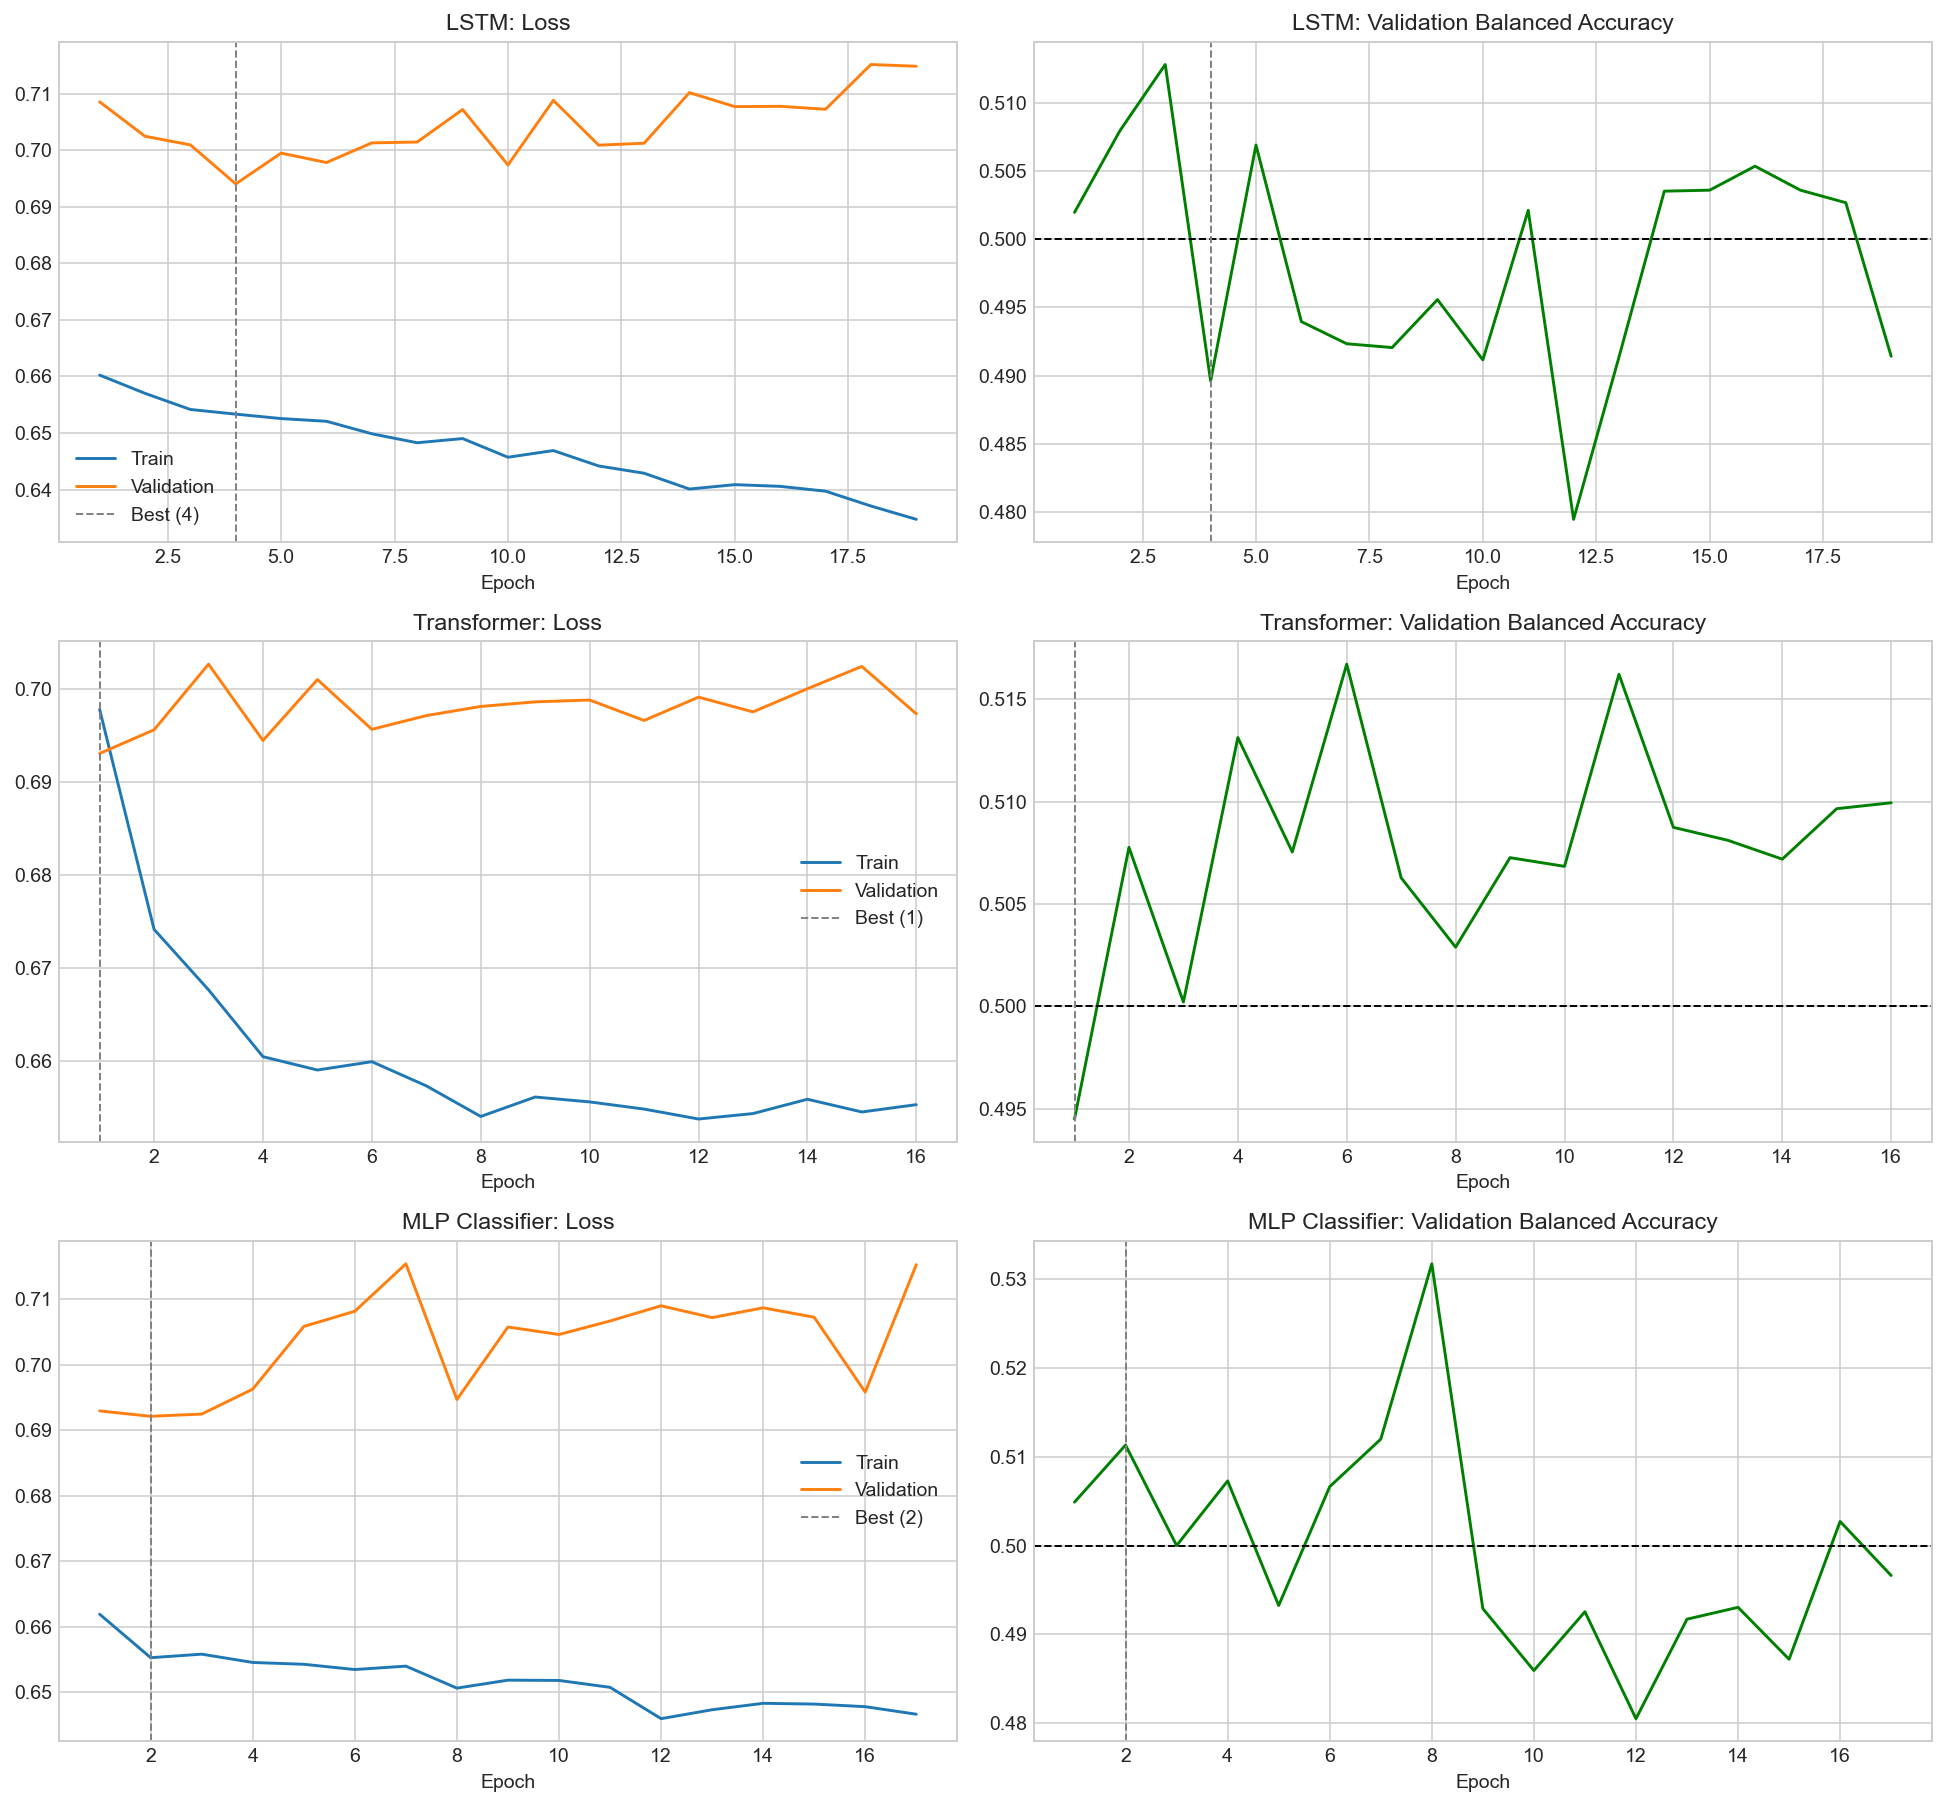

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 13))

for row, (hist, name) in enumerate([
    (lstm_history, "LSTM"),
    (tf_history,   "Transformer"),
    (mlp_history,  "MLP Classifier"),
]):
    best_ep = int(hist.loc[hist["val_loss"].idxmin(), "epoch"])

    axes[row, 0].plot(hist["epoch"], hist["train_loss"], label="Train")
    axes[row, 0].plot(hist["epoch"], hist["val_loss"],   label="Validation")
    axes[row, 0].axvline(best_ep, linestyle="--", color="gray", linewidth=1,
                         label=f"Best ({best_ep})")
    axes[row, 0].set_title(f"{name}: Loss")
    axes[row, 0].set_xlabel("Epoch"); axes[row, 0].legend()

    axes[row, 1].plot(hist["epoch"], hist["val_bal_acc"], color="green")
    axes[row, 1].axhline(0.5, linestyle="--", color="black", linewidth=1)
    axes[row, 1].axvline(best_ep, linestyle="--", color="gray", linewidth=1)
    axes[row, 1].set_title(f"{name}: Validation Balanced Accuracy")
    axes[row, 1].set_xlabel("Epoch")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "training_curves.svg", bbox_inches="tight")
plt.show()

In [ ]:
dl_outputs = {}
for model, name, notes in [
    (lstm_model, "LSTM",
     f"1-layer LSTM hidden={LSTM_HIDDEN_DIM} seq={SEQ_LEN} drop={LSTM_DROPOUT}"),
    (tf_model, "Transformer",
     f"1-layer Transformer d_model={TF_D_MODEL} heads={TF_NHEAD} seq={SEQ_LEN}"),
]:
    _, vp, vl = eval_loader(model, val_loader,  cls_val_criterion)
    _, tp, tl = eval_loader(model, test_loader, cls_val_criterion)
    all_results.append(flat_row(
        name, notes,
        get_scores(vl, (vp >= 0.5).astype(int), vp),
        get_scores(tl, (tp >= 0.5).astype(int), tp),
    ))
    dl_outputs[name] = {
        "val_probs": vp,   "val_labels": vl,
        "test_probs": tp,  "test_labels": tl,
        "test_preds": (tp >= 0.5).astype(int),
    }
print("Deep learning evaluation done.")

Deep learning evaluation done.


## Results: Full Model Comparison

All five models evaluated on the same test window (2019-01-02 to 2021-03-30).

In [ ]:
results_df = pd.DataFrame(all_results)

# Sort: benchmarks last, trained models first (by test balanced accuracy)
trained_mask = ~results_df["model"].isin(["Majority Class", "Persistence"])
trained_part = results_df[trained_mask].sort_values("test_balanced_accuracy", ascending=False)
bench_part   = results_df[~trained_mask].sort_values("test_balanced_accuracy", ascending=False)
results_df   = pd.concat([trained_part, bench_part], ignore_index=True)

metric_cols = [c for c in results_df.columns if c.startswith(("validation_", "test_"))]
display_df  = results_df.copy()
display_df[metric_cols] = display_df[metric_cols].round(4)

display(display_df[["model", "test_balanced_accuracy", "test_roc_auc",
                     "test_accuracy", "test_f1",
                     "validation_balanced_accuracy", "validation_roc_auc"]])

results_df.to_csv(TABLES_DIR / "full_model_comparison.csv", index=False)
print(f"Saved: {TABLES_DIR / 'full_model_comparison.csv'}")

,model,test_balanced_accuracy,test_roc_auc,test_accuracy,test_f1,validation_balanced_accuracy,validation_roc_auc
0,XGBoost,0.5355,0.5453,0.5327,0.5629,0.5136,0.4922
1,MLP,0.5193,0.5042,0.5540,0.6567,0.5113,0.5070
2,Transformer,0.5156,0.5259,0.5912,0.7366,0.4945,0.5041
3,Logistic Regression,0.4965,0.4981,0.4460,0.2771,0.4999,0.5004
4,LSTM,0.4844,0.5067,0.4850,0.5237,0.4896,0.5023
5,Majority Class,0.5000,NaN,0.5805,0.7346,0.5000,NaN
6,Persistence,0.4694,NaN,0.4832,0.5549,0.4981,NaN


Saved: C:\Users\clara\OneDrive\Documents\DissWork\results\tables\full_model_comparison.csv


## Visualisations

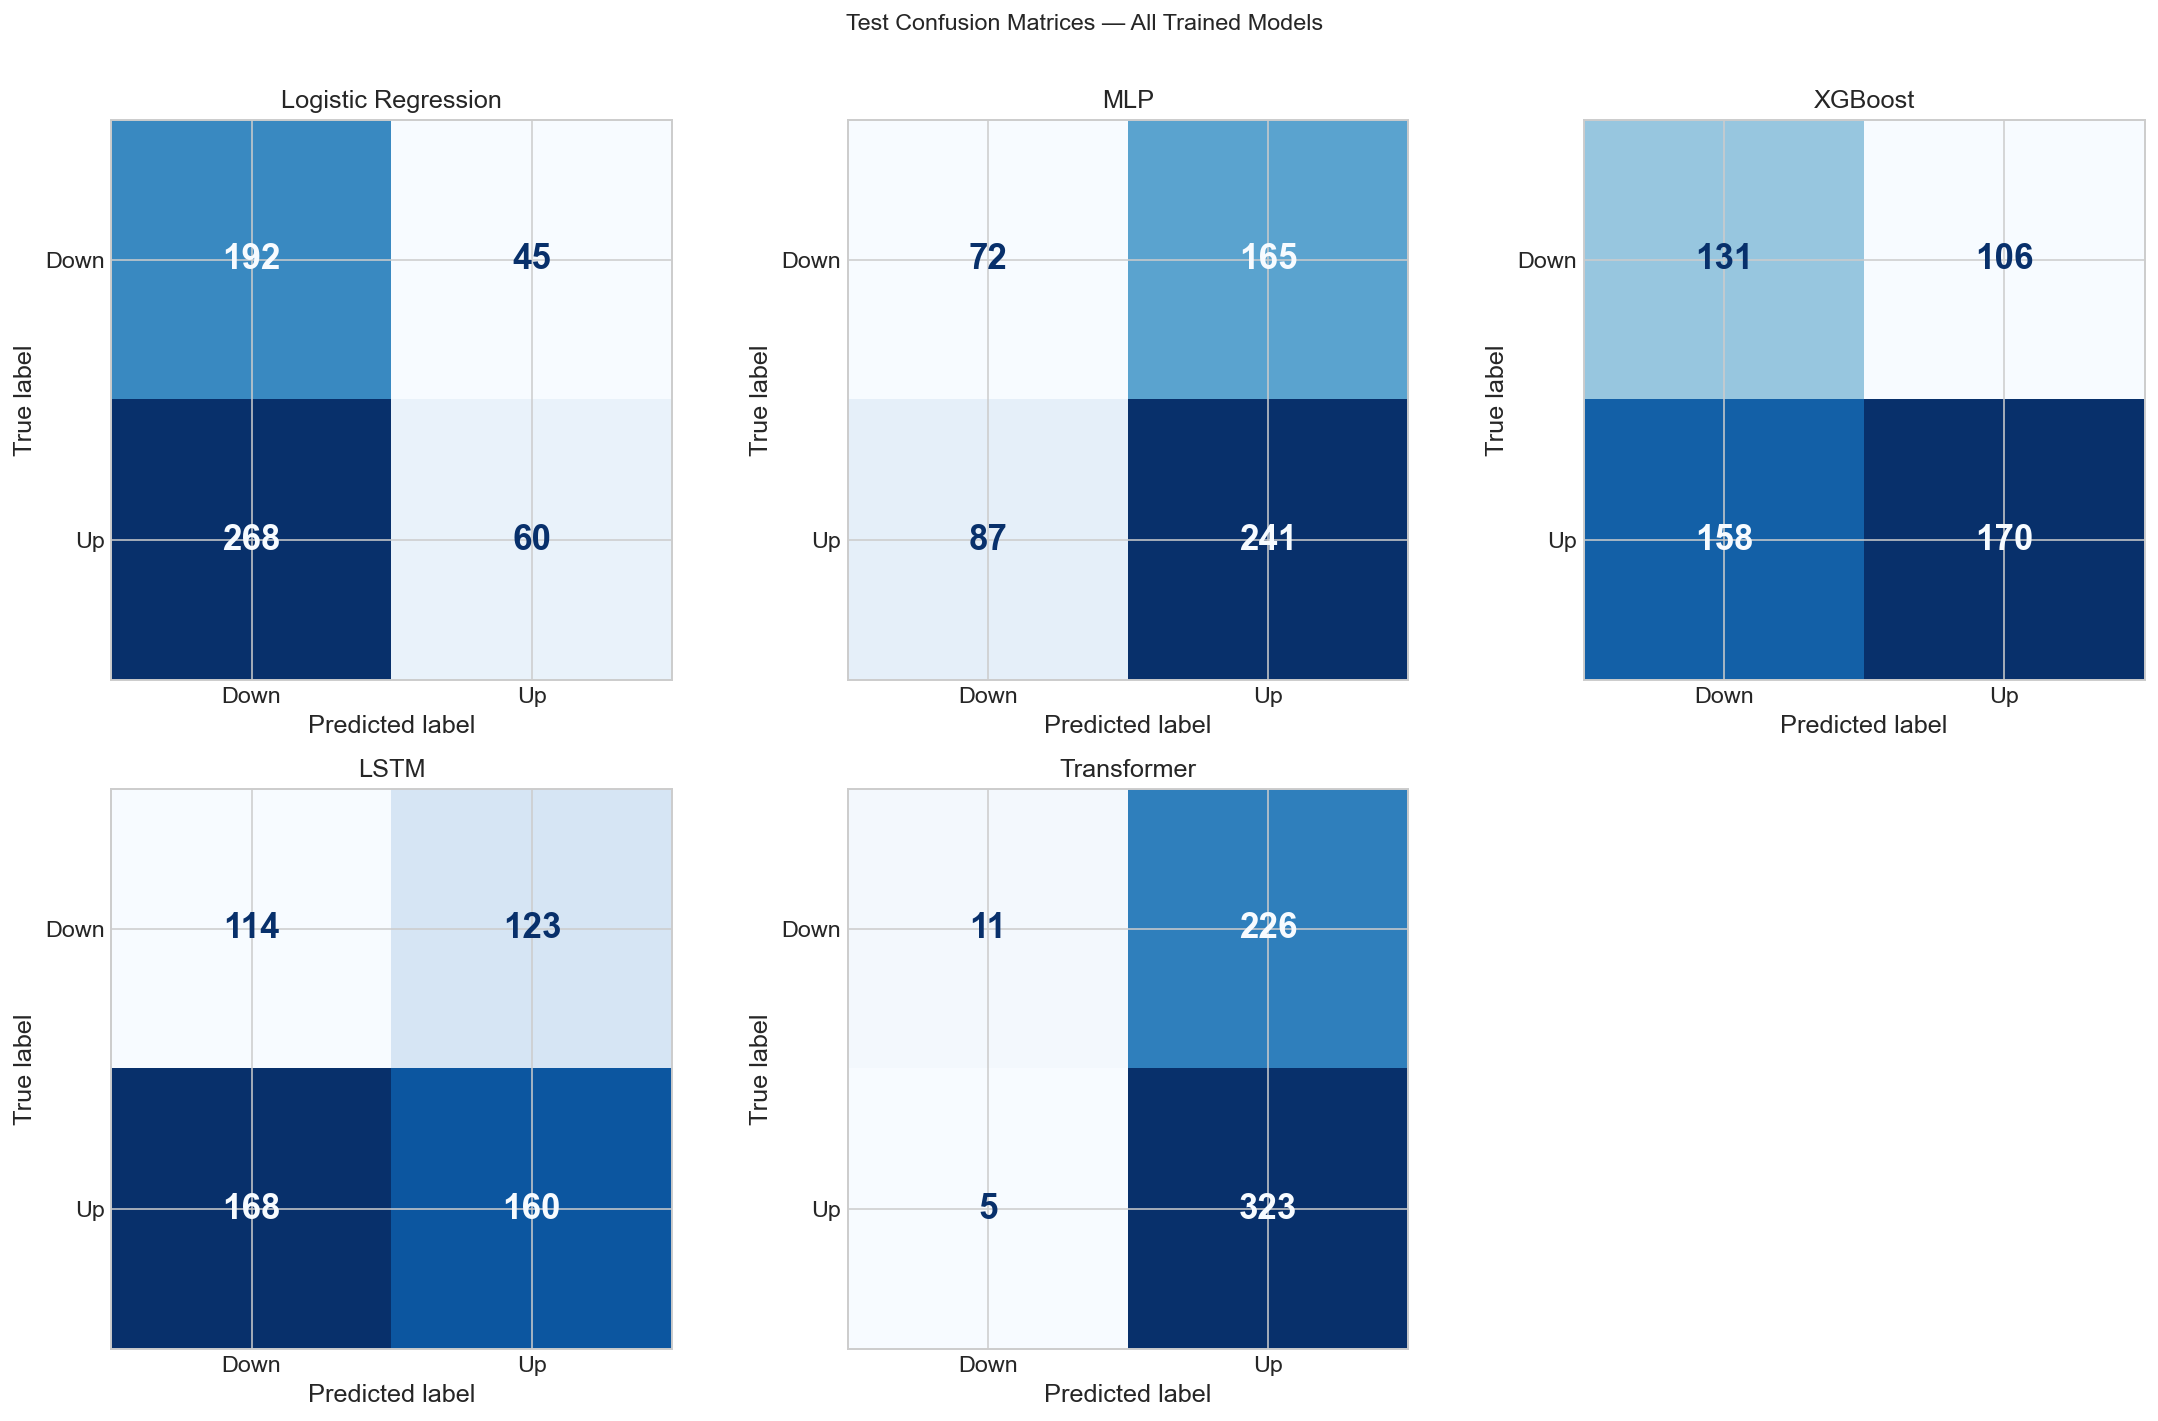

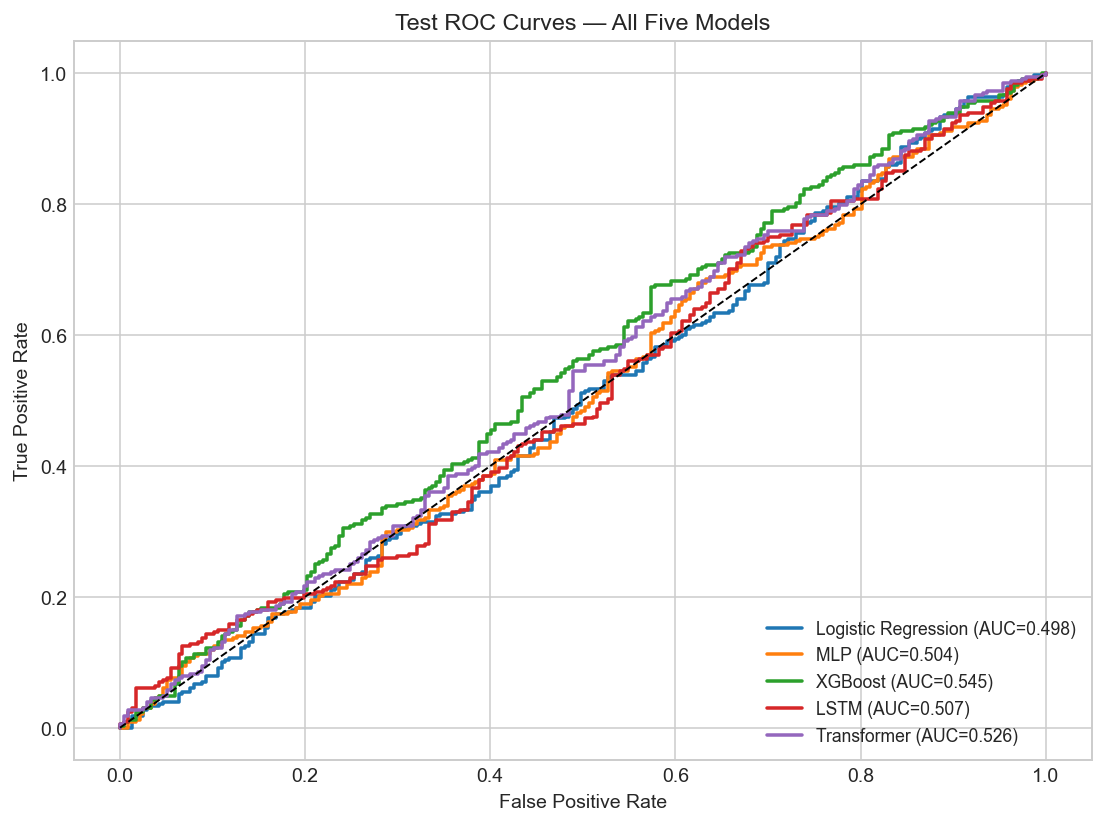

Figures saved to: C:\Users\clara\OneDrive\Documents\DissWork\results\figures\model_comparison


In [ ]:
# ── Confusion matrices (trained models only) ──────────────────────────────
trained_preds = {
    "Logistic Regression": (y_test, lr_tp),
    "MLP":                 (y_test, mlp_tp),
    TREE_MODEL_LABEL:      (y_test, tree_tp),
    "LSTM":                (test_df[TARGET_COLUMN].values, dl_outputs["LSTM"]["test_preds"]),
    "Transformer":         (test_df[TARGET_COLUMN].values, dl_outputs["Transformer"]["test_preds"]),
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes_flat = axes.flatten()

for ax, (name, (yt, yp)) in zip(axes_flat, trained_preds.items()):
    ConfusionMatrixDisplay(
        confusion_matrix(yt, yp), display_labels=["Down", "Up"],
    ).plot(ax=ax, colorbar=False, values_format="d", cmap="Blues",
           text_kw={"fontsize": 18, "fontweight": "bold"})
    ax.set_title(f"{name}", fontsize=13)
    ax.set_xlabel(ax.get_xlabel(), fontsize=13)
    ax.set_ylabel(ax.get_ylabel(), fontsize=13)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=12)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)

axes_flat[-1].set_visible(False)   # hide unused subplot
fig.suptitle("Test Confusion Matrices — All Trained Models", y=1.01)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "confusion_matrices_all_models.svg", bbox_inches="tight")
plt.show()

# ── ROC curves (probabilistic models) ────────────────────────────────────────────
roc_inputs = [
    ("Logistic Regression", y_test, lr_ts),
    ("MLP",                 y_test, mlp_ts),
    (TREE_MODEL_LABEL,      y_test, tree_ts),
    ("LSTM",        dl_outputs["LSTM"]["test_labels"],        dl_outputs["LSTM"]["test_probs"]),
    ("Transformer", dl_outputs["Transformer"]["test_labels"], dl_outputs["Transformer"]["test_probs"]),
]

fig2, ax2 = plt.subplots(figsize=(8, 6))
for name, yt, ys in roc_inputs:
    fpr, tpr, _ = roc_curve(yt, ys)
    auc = roc_auc_score(yt, ys)
    ax2.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", linewidth=1.8)

ax2.plot([0, 1], [0, 1], "k--", linewidth=1)
ax2.set_title("Test ROC Curves — All Five Models")
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.legend(loc="lower right", fontsize=9)
fig2.tight_layout()
fig2.savefig(FIGURES_DIR / "roc_curves_all_models.svg", bbox_inches="tight")
plt.show()

print(f"Figures saved to: {FIGURES_DIR}")

In [ ]:
if SAVE_MODEL_ARTIFACTS:
    # Sklearn models
    joblib.dump(lr_model,   MODEL_ARTIFACTS_DIR / "logistic_regression.joblib")
    joblib.dump(tree_model, MODEL_ARTIFACTS_DIR / f"{TREE_MODEL_LABEL.lower().replace(' ','_')}.joblib")
    # Sequence preprocessing
    joblib.dump(seq_imputer, MODEL_ARTIFACTS_DIR / "seq_imputer.joblib")
    joblib.dump(seq_scaler,  MODEL_ARTIFACTS_DIR / "seq_scaler.joblib")
    # PyTorch classification models
    torch.save(mlp_model.state_dict(),  MODEL_ARTIFACTS_DIR / "mlp.pt")
    torch.save(lstm_model.state_dict(), MODEL_ARTIFACTS_DIR / "lstm.pt")
    torch.save(tf_model.state_dict(),   MODEL_ARTIFACTS_DIR / "transformer.pt")
    # Training histories
    mlp_history.to_csv(MODEL_ARTIFACTS_DIR  / "mlp_history.csv",         index=False)
    lstm_history.to_csv(MODEL_ARTIFACTS_DIR / "lstm_history.csv",         index=False)
    tf_history.to_csv(MODEL_ARTIFACTS_DIR   / "transformer_history.csv",  index=False)
    print("Artefacts saved to:", MODEL_ARTIFACTS_DIR)

Artefacts saved to: C:\Users\clara\OneDrive\Documents\DissWork\models\trained


In [ ]:
best      = results_df[~results_df["model"].isin(["Majority Class","Persistence"])].iloc[0]
lstm_row  = results_df[results_df["model"] == "LSTM"].iloc[0]
tf_row    = results_df[results_df["model"] == "Transformer"].iloc[0]

lines = [
    "### Summary",
    "",
    f"- Best model by test balanced accuracy: **{best['model']}** ({best['test_balanced_accuracy']:.4f})",
    f"- LSTM test balanced accuracy: {lstm_row['test_balanced_accuracy']:.4f}  |  ROC-AUC: {lstm_row['test_roc_auc']:.4f}",
    f"- Transformer test balanced accuracy: {tf_row['test_balanced_accuracy']:.4f}  |  ROC-AUC: {tf_row['test_roc_auc']:.4f}",
    "",
    "All models achieve balanced accuracy close to 50%, consistent with the weak-form efficient market hypothesis "
    "(Fama, 1970). This is a well-documented result in daily equity prediction "
    "(Fischer & Krauss, 2018; Sezer et al., 2020) and is not evidence that the modelling exercise has failed — "
    "even a small, consistent edge above chance has practical value in a trading context.",
    "",
    "The deep learning models do not systematically outperform the tabular baselines, which is notable: "
    "it suggests that the temporal structure captured by LSTM and Transformer does not provide "
    "additional discriminative power beyond what XGBoost extracts from single-day feature snapshots at this frequency.",
]

try:
    display(Markdown("\n".join(lines)))
except Exception:
    print("\n".join(lines))

### Summary

- Best model by test balanced accuracy: **XGBoost** (0.5355)
- LSTM test balanced accuracy: 0.4844  |  ROC-AUC: 0.5067
- Transformer test balanced accuracy: 0.5156  |  ROC-AUC: 0.5259

All models achieve balanced accuracy close to 50%, consistent with the weak-form efficient market hypothesis (Fama, 1970). This is a well-documented result in daily equity prediction (Fischer & Krauss, 2018; Sezer et al., 2020) and is not evidence that the modelling exercise has failed — even a small, consistent edge above chance has practical value in a trading context.

The deep learning models do not systematically outperform the tabular baselines, which is notable: it suggests that the temporal structure captured by LSTM and Transformer does not provide additional discriminative power beyond what XGBoost extracts from single-day feature snapshots at this frequency.

---

## Regression Study: Predicting Next-Day Return

The second half of this notebook addresses the **regression task**: predicting SPY's next-day percentage return (`target_next_return`) using the same 54+ features and the same chronological train/validation/test splits as the classification study above.

Predicting a continuous return is a strictly harder problem than predicting its sign. Regression metrics — RMSE, MAE, R² — reveal whether models can capture any of the variance in daily returns, even when directional accuracy near 50% suggests they cannot reliably predict the sign. The two sets of results together give a more complete picture of each model family's predictive power.

**Why `target_next_return` rather than `target_next_close`?** Next-day returns are stationary (mean-reverting around zero with no trend), which makes them well-suited to regression: errors are directly comparable across different price levels and time periods. Raw closing prices are non-stationary and heavily trend-driven, meaning a naive model that predicts "tomorrow ≈ today" would appear to perform well on MSE simply because prices move slowly. Using returns isolates whether models genuinely capture daily price variation.

The regression counterpart to each classification model is trained immediately after the existing classification pipeline and evaluated on the same test window (2019-01-02 → 2021-03-30).

In [ ]:
# ── Regression targets from the existing splits ───────────────────────────
# The regression target (next-day return) is already in model_df alongside
# the classification target. We extract it from the same chronological splits
# so feature rows are identical; only the y-vector changes.

y_train_reg = train_df[REGRESSION_TARGET].values.astype(np.float64)
y_val_reg   = val_df[REGRESSION_TARGET].values.astype(np.float64)
y_test_reg  = test_df[REGRESSION_TARGET].values.astype(np.float64)

# X_train / X_val / X_test (feature matrices) are reused unchanged from above.

print(f"Regression target : {REGRESSION_TARGET}")
print(f"Train y shape     : {y_train_reg.shape}  mean={y_train_reg.mean():.5f}  std={y_train_reg.std():.5f}")
print(f"Validation y shape: {y_val_reg.shape}    mean={y_val_reg.mean():.5f}  std={y_val_reg.std():.5f}")
print(f"Test y shape      : {y_test_reg.shape}   mean={y_test_reg.mean():.5f}  std={y_test_reg.std():.5f}")

regression_results: List[dict] = []

Regression target : target_next_return
Train y shape     : (4732,)  mean=0.00023  std=0.01227
Validation y shape: (502,)    mean=0.00024  std=0.00820
Test y shape      : (565,)   mean=0.00093  std=0.01539


In [ ]:
def get_regression_scores(y_true, y_pred) -> dict:
    """Compute MAE, RMSE, and R² for a regression prediction."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return {"mae": mae, "rmse": rmse, "r2": r2}


def flat_row_reg(name: str, notes: str, val_m: dict, test_m: dict) -> dict:
    """Same flat-row structure as classification but for regression metrics."""
    row = {"model": name, "notes": notes}
    for pfx, m in [("validation", val_m), ("test", test_m)]:
        for k, v in m.items():
            row[f"{pfx}_{k}"] = v
    return row

## Naive Regression Benchmarks

Two trivial regression baselines establish the irreducible performance floor before any trained model is introduced.

**Persistence (Regression)** — predicts that tomorrow's return equals today's return (first-order autocorrelation assumption). This is the regression analogue of the classification Persistence benchmark.

**Historical Mean** — predicts that tomorrow's return equals the mean return observed in the training set. Because daily returns are approximately zero-mean, this benchmark is similar in spirit to always predicting zero — it minimises in-sample MSE under a constant-predictor assumption. Any model that cannot beat this on RMSE has learned nothing beyond the unconditional mean.

In [ ]:
# ── Persistence (Regression): predict tomorrow = today's return ───────────
per_val_reg  = val_df["return_1d"].values.astype(np.float64)
per_test_reg = test_df["return_1d"].values.astype(np.float64)

regression_results.append(flat_row_reg(
    "Persistence",
    "Predicts tomorrow's return = today's return (first-order autocorrelation).",
    get_regression_scores(y_val_reg,  per_val_reg),
    get_regression_scores(y_test_reg, per_test_reg),
))

# ── Historical Mean: predict tomorrow = training-set mean return ──────────
train_mean_return = float(y_train_reg.mean())
mean_val_reg  = np.full_like(y_val_reg,  fill_value=train_mean_return)
mean_test_reg = np.full_like(y_test_reg, fill_value=train_mean_return)

regression_results.append(flat_row_reg(
    "Historical Mean",
    f"Predicts tomorrow's return = training mean ({train_mean_return:.5f}).",
    get_regression_scores(y_val_reg,  mean_val_reg),
    get_regression_scores(y_test_reg, mean_test_reg),
))

print(f"Training mean return  : {train_mean_return:.6f}")
print("Naive regression benchmarks done.")

Training mean return  : 0.000230
Naive regression benchmarks done.


## 1 — Ridge Regression

The regression counterpart to Logistic Regression. Ridge (L2-regularised linear regression) imposes the same linear inductive bias as its classification counterpart, making the comparison between the two tasks transparent: differences in performance stem solely from the nature of the output (sign vs. magnitude), not from architectural differences.

The same preprocessing pipeline (median imputation + standardisation, fitted on training data only) is applied to keep the experimental design consistent.

In [ ]:
ridge_model = Pipeline([
    ("imputer",    SimpleImputer(strategy="median")),
    ("scaler",     StandardScaler()),
    ("regressor",  Ridge(alpha=1.0, random_state=RANDOM_SEED)),
])
ridge_model.fit(X_train, y_train_reg)

ridge_vp = ridge_model.predict(X_val)
ridge_tp = ridge_model.predict(X_test)

regression_results.append(flat_row_reg(
    "Ridge Regression",
    "L2-regularised linear regression; train-only median imputation and standardisation.",
    get_regression_scores(y_val_reg,  ridge_vp),
    get_regression_scores(y_test_reg, ridge_tp),
))

if SAVE_MODEL_ARTIFACTS:
    joblib.dump(ridge_model, MODEL_ARTIFACTS_DIR / "ridge_regression.joblib")

print("Ridge Regression done.")

Ridge Regression done.


## 2 — MLP Regressor (PyTorch)

The regression counterpart to the MLP Classifier. Architecture is identical — two hidden layers of (128, 64) units with ReLU activations and dropout 0.5 — but the output head is a single linear unit (no sigmoid) that predicts a continuous next-day return.

Implemented in PyTorch using `nn.L1Loss` (MAE) to match the LSTM and Transformer regressors. Training uses sequence loaders built from the same imputed-and-scaled feature matrix (`X_scaled`) and chronological index arrays (`train_idx`, `val_idx`) so the training data is identical to the LSTM and Transformer regressors. Final predictions are obtained via single-step inference on `X_scaled[val_idx]` and `X_scaled[test_idx]`, giving arrays of the same length as `y_val_reg` and `y_test_reg`.

In [ ]:
# ── PyTorch MLP Regressor ──────────────────────────────────────────────────────
class MLPRegressor(nn.Module):
    """Two-hidden-layer MLP (128 → 64) with linear output for regression."""
    def __init__(self, input_dim: int, dropout: float = 0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128,        64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.dim() == 3:
            x = x[:, -1, :]   # sequence input: take last timestep only
        return self.net(x).squeeze(-1)


mlp_reg_model = MLPRegressor(n_features, dropout=0.5).to(DEVICE)
print(f"MLP Regressor params: {sum(p.numel() for p in mlp_reg_model.parameters() if p.requires_grad):,}")

# ── Sequence loaders — same data as reg_train_loader / reg_val_loader below ───
_y_reg = model_df[REGRESSION_TARGET].values.astype(np.float32)
_mlp_reg_train_ld = DataLoader(
    SequenceDataset(X_scaled, _y_reg, SEQ_LEN, train_idx),
    batch_size=BATCH_SIZE, shuffle=True,
)
_mlp_reg_val_ld = DataLoader(
    SequenceDataset(X_scaled, _y_reg, SEQ_LEN, val_idx),
    batch_size=BATCH_SIZE, shuffle=False,
)

print("Training MLP Regressor...")
mlp_reg_criterion = nn.L1Loss()
mlp_reg_history, _, _ = run_training(
    mlp_reg_model, "MLP Regressor",
    _mlp_reg_train_ld, _mlp_reg_val_ld,
    train_criterion=mlp_reg_criterion,
    task="regression",
)

# ── Inference: tabular-length predictions matching y_val_reg / y_test_reg ─────
@torch.no_grad()
def _mlp_reg_predict(X_np: np.ndarray) -> np.ndarray:
    mlp_reg_model.eval()
    X_t = torch.tensor(X_np, dtype=torch.float32).to(DEVICE)
    return mlp_reg_model(X_t).cpu().numpy()

mlp_reg_vp = _mlp_reg_predict(X_scaled[val_idx])
mlp_reg_tp = _mlp_reg_predict(X_scaled[test_idx])

regression_results.append(flat_row_reg(
    "MLP Regressor",
    f"PyTorch MLP (128->64) ReLU drop=0.5; MAE loss; Adam lr={LR} wd={WEIGHT_DECAY}.",
    get_regression_scores(y_val_reg,  mlp_reg_vp),
    get_regression_scores(y_test_reg, mlp_reg_tp),
))

if SAVE_MODEL_ARTIFACTS:
    torch.save(mlp_reg_model.state_dict(), MODEL_ARTIFACTS_DIR / "mlp_regressor.pt")
    mlp_reg_history.to_csv(MODEL_ARTIFACTS_DIR / "mlp_regressor_history.csv", index=False)

print("MLP Regressor done.")

MLP Regressor params: 17,281
Training MLP Regressor...
[MLP Regressor] epoch   1 | tr=0.0603  vl=0.0112  val_rmse=0.0131  lr=1.0e-03
[MLP Regressor] epoch  10 | tr=0.0085  vl=0.0052  val_rmse=0.0082  lr=1.0e-03
[MLP Regressor] Early stop at epoch 19.
[MLP Regressor] Best val loss: 0.0052  (18.2s)
MLP Regressor done.


## 3 — XGBoost Regressor

The regression counterpart to the XGBoost Classifier. Hyperparameters are matched exactly (300 estimators, learning rate 0.05, max depth 4, subsample 0.8, column subsample 0.8) so that any difference between classification and regression performance reflects the task difficulty rather than a modelling advantage.

In [ ]:
if XGBOOST_AVAILABLE:
    from xgboost import XGBRegressor
    tree_reg_clf = XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=RANDOM_SEED, n_jobs=-1,
    )
else:
    from sklearn.ensemble import RandomForestRegressor
    tree_reg_clf = RandomForestRegressor(
        n_estimators=500, max_depth=6, min_samples_leaf=20,
        max_features="sqrt", random_state=RANDOM_SEED, n_jobs=-1,
    )

TREE_REG_LABEL = "XGBoost Regressor" if XGBOOST_AVAILABLE else "Random Forest Regressor"

tree_reg_model = Pipeline([
    ("imputer",   SimpleImputer(strategy="median")),
    ("regressor", tree_reg_clf),
])
tree_reg_model.fit(X_train, y_train_reg)

tree_reg_vp = tree_reg_model.predict(X_val)
tree_reg_tp = tree_reg_model.predict(X_test)

regression_results.append(flat_row_reg(
    TREE_REG_LABEL,
    f"Gradient-boosted tree ensemble ({TREE_REG_LABEL}); train-only imputation.",
    get_regression_scores(y_val_reg,  tree_reg_vp),
    get_regression_scores(y_test_reg, tree_reg_tp),
))

if SAVE_MODEL_ARTIFACTS:
    joblib.dump(tree_reg_model, MODEL_ARTIFACTS_DIR / f"{TREE_REG_LABEL.lower().replace(' ', '_')}.joblib")

print(f"{TREE_REG_LABEL} done.")

XGBoost Regressor done.


## Sequence Preprocessing (LSTM and Transformer Regressors)

The regression sequence models reuse the **same imputed and scaled feature matrix** (`X_scaled`) fitted during the classification preprocessing step — the scaler was fitted on training rows only and no re-fitting is required. The only change is that the label vector is replaced with `target_next_return` (continuous) instead of `target_direction` (binary).

New `DataLoader` objects are constructed with this continuous label vector. Split membership is determined by the date of each sequence's **last** timestep, identical to the classification setup.

In [ ]:
# Continuous regression labels aligned to the full SPY index
y_reg_seq = model_df[REGRESSION_TARGET].values.astype(np.float32)

# Reuse the same train/val/test index arrays (train_idx, val_idx, test_idx)
# and X_scaled from the classification sequence preprocessing above.
reg_train_loader = DataLoader(
    SequenceDataset(X_scaled, y_reg_seq, SEQ_LEN, train_idx),
    batch_size=BATCH_SIZE, shuffle=True,
)
reg_val_loader = DataLoader(
    SequenceDataset(X_scaled, y_reg_seq, SEQ_LEN, val_idx),
    batch_size=BATCH_SIZE, shuffle=False,
)
reg_test_loader = DataLoader(
    SequenceDataset(X_scaled, y_reg_seq, SEQ_LEN, test_idx),
    batch_size=BATCH_SIZE, shuffle=False,
)

print(f"Regression sequences — train: {len(train_idx)}  val: {len(val_idx)}  test: {len(test_idx)}")

Regression sequences — train: 4713  val: 502  test: 565


## Deep Learning Regression Architectures

The regression architectures are structurally identical to their classification counterparts — the same LSTM stack and Transformer encoder — but differ in two ways:

1. **Output head**: a single linear unit (no sigmoid activation) that produces an unbounded real-valued prediction.
2. **Loss function**: MAE (`nn.L1Loss`) replaces BCE; the training loop no longer uses a `pos_weight` correction since there is no class imbalance in a regression target.

Early stopping, `ReduceLROnPlateau`, and gradient clipping are retained unchanged. The `run_training_regression` function below is a minimal adaptation of `run_training` that tracks validation RMSE instead of balanced accuracy.

In [ ]:
class LSTMRegressor(nn.Module):
    """Two-layer stacked LSTM with a single linear output (regression)."""
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm    = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers,
                               batch_first=True,
                               dropout=dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        self.head    = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.head(self.dropout(h_n[-1])).squeeze(-1)


class TransformerRegressor(nn.Module):
    """Two-layer Transformer encoder with a single linear output (regression)."""
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2,
                 dim_feedforward=128, dropout=0.1, max_seq_len=100):
        super().__init__()
        self.input_proj  = nn.Linear(input_dim, d_model)
        self.pos_embed   = nn.Embedding(max_seq_len, d_model)
        enc_layer        = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True, norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.dropout     = nn.Dropout(dropout)
        self.head        = nn.Linear(d_model, 1)

    def forward(self, x):
        B, T, _ = x.shape
        pos = torch.arange(T, device=x.device).unsqueeze(0).expand(B, -1)
        x   = self.input_proj(x) + self.pos_embed(pos)
        x   = self.transformer(x)
        return self.head(self.dropout(x[:, -1, :])).squeeze(-1)


lstm_reg_model = LSTMRegressor(n_features, LSTM_HIDDEN_DIM, LSTM_NUM_LAYERS, LSTM_DROPOUT).to(DEVICE)
tf_reg_model   = TransformerRegressor(n_features, TF_D_MODEL, TF_NHEAD, TF_NUM_LAYERS,
                                      TF_DIM_FF, TF_DROPOUT, max_seq_len=SEQ_LEN + 10).to(DEVICE)

print(f"LSTM Regressor params       : {sum(p.numel() for p in lstm_reg_model.parameters() if p.requires_grad):,}")
print(f"Transformer Regressor params: {sum(p.numel() for p in tf_reg_model.parameters() if p.requires_grad):,}")

LSTM Regressor params       : 13,217
Transformer Regressor params: 11,777


## 4 — LSTM Regressor

A single-layer LSTM with a single linear output head. The architecture is identical to the LSTM Classifier except the final sigmoid is removed and MAE loss is used. Early stopping monitors validation MAE.

In [ ]:
print("Training LSTM Regressor...")
reg_criterion = nn.L1Loss()
lstm_reg_history, _, _ = run_training(
    lstm_reg_model, "LSTM Regressor",
    reg_train_loader, reg_val_loader, reg_criterion, task="regression",
)

Training LSTM Regressor...
[LSTM Regressor] epoch   1 | tr=0.1008  vl=0.0295  val_rmse=0.0340  lr=1.0e-03
[LSTM Regressor] epoch  10 | tr=0.0086  vl=0.0053  val_rmse=0.0082  lr=1.0e-03
[LSTM Regressor] epoch  20 | tr=0.0086  vl=0.0052  val_rmse=0.0082  lr=1.0e-03
[LSTM Regressor] epoch  30 | tr=0.0084  vl=0.0053  val_rmse=0.0082  lr=5.0e-04
[LSTM Regressor] epoch  40 | tr=0.0084  vl=0.0052  val_rmse=0.0082  lr=2.5e-04
[LSTM Regressor] Early stop at epoch 44.
[LSTM Regressor] Best val loss: 0.0052  (45.1s)


## 5 — Transformer Regressor

A single-layer Transformer encoder with learnable positional embeddings and Pre-LayerNorm, identical in structure to the Transformer Classifier. The output at the final sequence position is projected to a single real value via a linear head, and MAE loss drives training.

In [ ]:
print("Training Transformer Regressor...")
tf_reg_history, _, _ = run_training(
    tf_reg_model, "Transformer Regressor",
    reg_train_loader, reg_val_loader, reg_criterion, task="regression",
)

Training Transformer Regressor...
[Transformer Regressor] epoch   1 | tr=0.3602  vl=0.0392  val_rmse=0.0555  lr=1.0e-03
[Transformer Regressor] epoch  10 | tr=0.0093  vl=0.0052  val_rmse=0.0083  lr=1.0e-03
[Transformer Regressor] epoch  20 | tr=0.0088  vl=0.0053  val_rmse=0.0083  lr=5.0e-04
[Transformer Regressor] Early stop at epoch 25.
[Transformer Regressor] Best val loss: 0.0052  (43.9s)


## Regression Training Curves

Training and validation MAE loss and validation RMSE trajectories for all three PyTorch regression models: LSTM Regressor, Transformer Regressor, and MLP Regressor. The best-epoch marker indicates the early-stopping checkpoint.

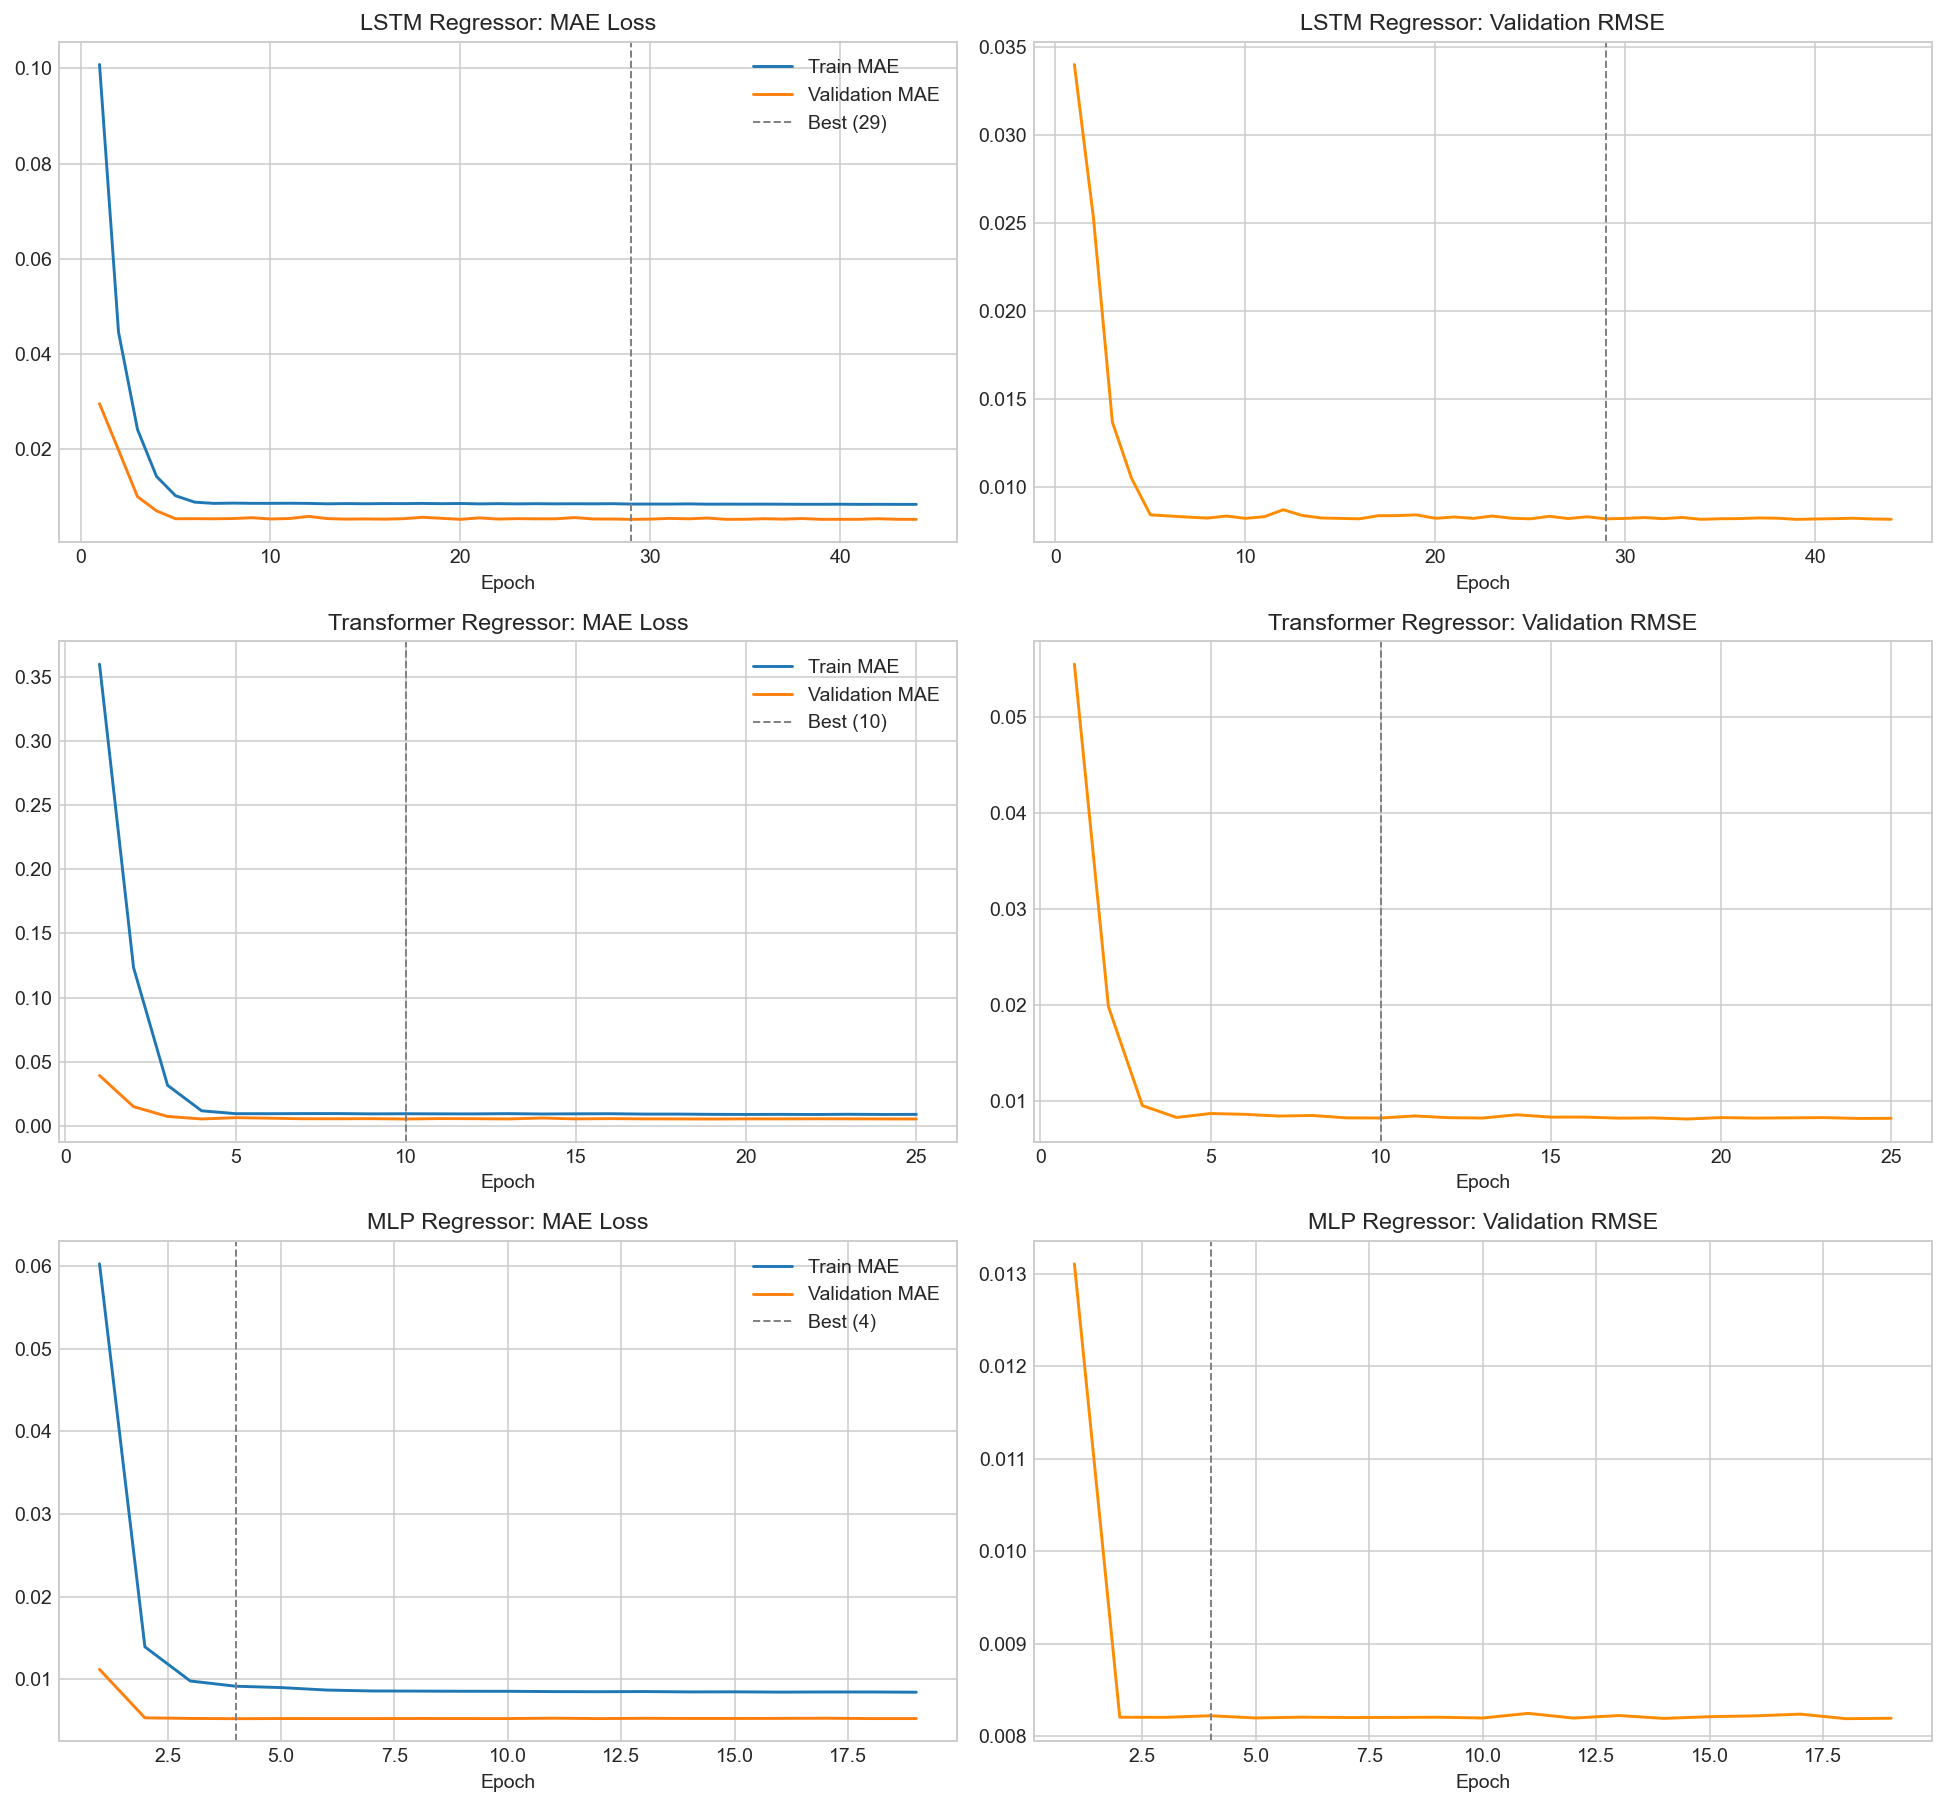

Saved: C:\Users\clara\OneDrive\Documents\DissWork\results\figures\model_comparison\regression_training_curves.svg


In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 13))

for row, (hist, name) in enumerate([
    (lstm_reg_history, "LSTM Regressor"),
    (tf_reg_history,   "Transformer Regressor"),
    (mlp_reg_history,  "MLP Regressor"),
]):
    best_ep = int(hist.loc[hist["val_loss"].idxmin(), "epoch"])

    axes[row, 0].plot(hist["epoch"], hist["train_loss"], label="Train MAE")
    axes[row, 0].plot(hist["epoch"], hist["val_loss"],   label="Validation MAE")
    axes[row, 0].axvline(best_ep, linestyle="--", color="gray", linewidth=1,
                         label=f"Best ({best_ep})")
    axes[row, 0].set_title(f"{name}: MAE Loss")
    axes[row, 0].set_xlabel("Epoch")
    axes[row, 0].legend()

    axes[row, 1].plot(hist["epoch"], hist["val_rmse"], color="darkorange")
    axes[row, 1].axvline(best_ep, linestyle="--", color="gray", linewidth=1)
    axes[row, 1].set_title(f"{name}: Validation RMSE")
    axes[row, 1].set_xlabel("Epoch")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "regression_training_curves.svg", bbox_inches="tight")
plt.show()
print(f"Saved: {FIGURES_DIR / 'regression_training_curves.svg'}")

In [ ]:
reg_criterion = nn.L1Loss()
dl_reg_outputs = {}

for model, name, notes in [
    (lstm_reg_model, "LSTM Regressor",
     f"1-layer LSTM hidden={LSTM_HIDDEN_DIM} seq={SEQ_LEN} drop={LSTM_DROPOUT}; MAE loss"),
    (tf_reg_model, "Transformer Regressor",
     f"1-layer Transformer d_model={TF_D_MODEL} heads={TF_NHEAD} seq={SEQ_LEN}; MAE loss"),
]:
    _, vp, vl_true = eval_loader(model, reg_val_loader,  reg_criterion, apply_sigmoid=False)
    _, tp, tl_true = eval_loader(model, reg_test_loader, reg_criterion, apply_sigmoid=False)
    regression_results.append(flat_row_reg(
        name, notes,
        get_regression_scores(vl_true, vp),
        get_regression_scores(tl_true, tp),
    ))
    dl_reg_outputs[name] = {
        "test_preds":  tp,
        "test_labels": tl_true,
        "test_dates":  test_df[DATE_COLUMN].iloc[
            test_idx - test_idx.min()
        ].reset_index(drop=True),
    }

if SAVE_MODEL_ARTIFACTS:
    torch.save(lstm_reg_model.state_dict(), MODEL_ARTIFACTS_DIR / "lstm_regressor.pt")
    torch.save(tf_reg_model.state_dict(),   MODEL_ARTIFACTS_DIR / "transformer_regressor.pt")
    lstm_reg_history.to_csv(MODEL_ARTIFACTS_DIR / "lstm_regressor_history.csv", index=False)
    tf_reg_history.to_csv(MODEL_ARTIFACTS_DIR   / "transformer_regressor_history.csv", index=False)
    print("Regression deep learning artefacts saved.")

print("Deep learning regression evaluation done.")

Regression deep learning artefacts saved.
Deep learning regression evaluation done.


## Results: Regression Model Comparison

All seven regression models (five trained + two naive benchmarks) evaluated on the same test window (2019-01-02 to 2021-03-30), ordered by test RMSE. Lower RMSE and MAE indicate better fit; higher R² (maximum 1.0) indicates more explained variance. Negative R² means the model is worse than simply predicting the training mean.

In [ ]:
regression_df = pd.DataFrame(regression_results)

# Sort: benchmarks last, trained models first (by test RMSE ascending)
bench_names  = ["Persistence", "Historical Mean"]
trained_mask = ~regression_df["model"].isin(bench_names)
trained_part = regression_df[trained_mask].sort_values("test_rmse", ascending=True)
bench_part   = regression_df[~trained_mask].sort_values("test_rmse", ascending=True)
regression_df = pd.concat([trained_part, bench_part], ignore_index=True)

metric_cols = [c for c in regression_df.columns if c.startswith(("validation_", "test_"))]
display_df  = regression_df.copy()
display_df[metric_cols] = display_df[metric_cols].round(6)

display(display_df[["model", "test_rmse", "test_mae", "test_r2",
                     "validation_rmse", "validation_mae", "validation_r2"]])

regression_df.to_csv(TABLES_DIR / "regression_model_comparison.csv", index=False)
print(f"Saved: {TABLES_DIR / 'regression_model_comparison.csv'}")

,model,test_rmse,test_mae,test_r2,validation_rmse,validation_mae,validation_r2
0,MLP Regressor,0.015318,0.009204,0.009834,0.008220,0.005219,-0.005784
1,LSTM Regressor,0.015338,0.009264,0.007300,0.008207,0.005232,-0.002695
2,Transformer Regressor,0.015485,0.009198,-0.011890,0.008270,0.005225,-0.018235
3,Ridge Regression,0.015899,0.009571,-0.066655,0.008249,0.005366,-0.012980
4,XGBoost Regressor,0.016507,0.009764,-0.149862,0.008509,0.005464,-0.077767
5,Historical Mean,0.015410,0.009294,-0.002091,0.008196,0.005243,-0.000002
6,Persistence,0.024636,0.014251,-1.561112,0.011657,0.007572,-1.022769


Saved: C:\Users\clara\OneDrive\Documents\DissWork\results\tables\regression_model_comparison.csv


## Regression Visualisations

Two figures summarise the regression results:

1. **RMSE bar chart** — compares test-set RMSE across all seven models in a single plot, with the Historical Mean baseline highlighted as a reference line.
2. **Predicted vs actual time-series overlay** — shows the best-performing trained regression model's test-set predictions against the realised returns, revealing where the model tracks the signal and where it diverges.

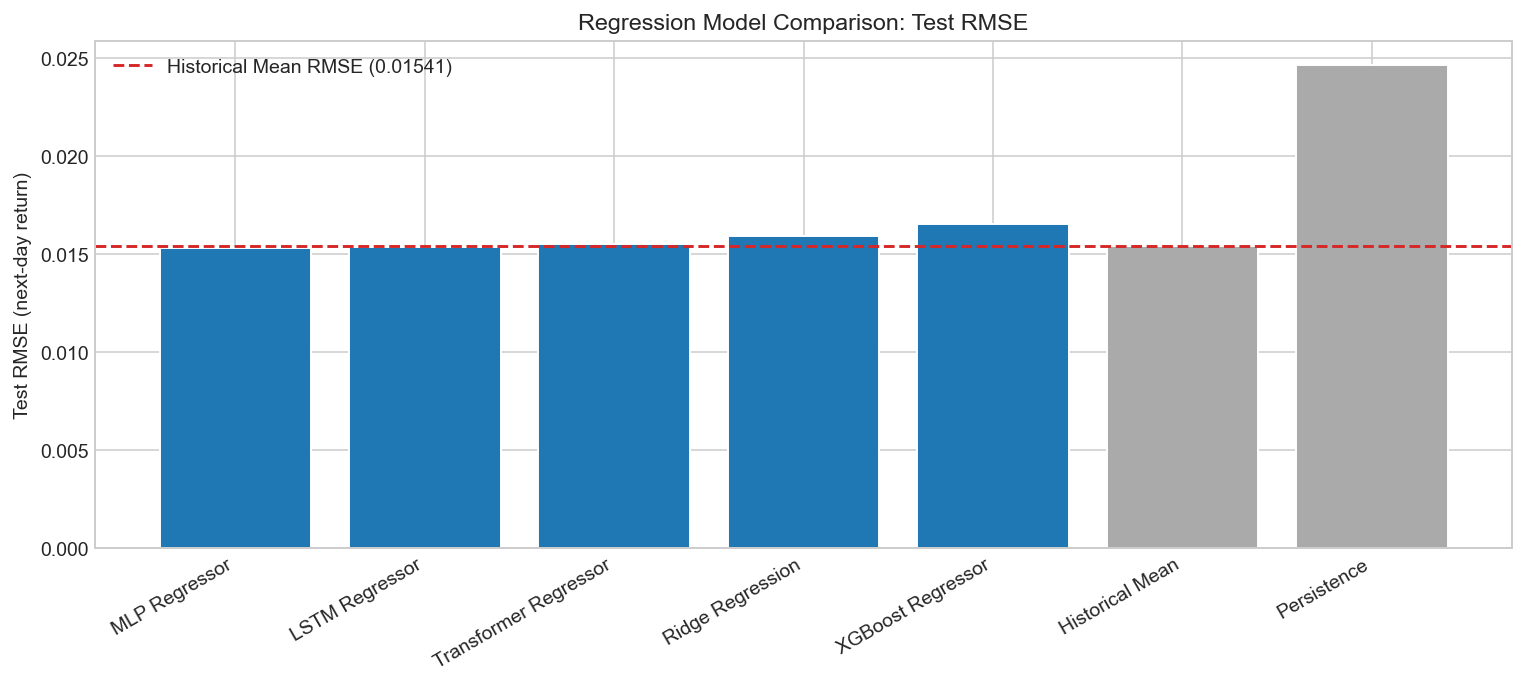

Saved → C:\Users\clara\OneDrive\Documents\DissWork\results\figures\model_comparison\regression_rmse_comparison.svg


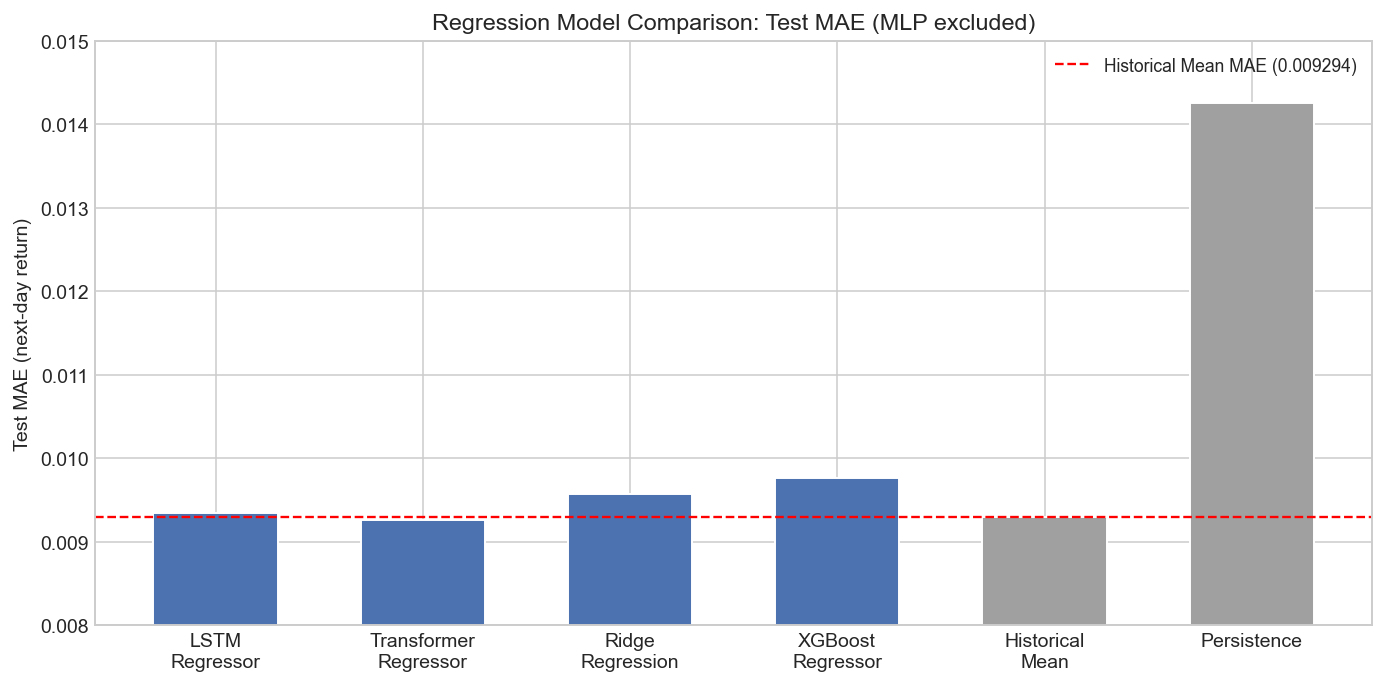

In [ ]:
# ── Figure 1: RMSE bar chart ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

colors = ["#1f77b4" if m not in bench_names else "#aaaaaa"
          for m in regression_df["model"]]
bars = ax.bar(regression_df["model"], regression_df["test_rmse"], color=colors, edgecolor="white")

# Reference line: Historical Mean RMSE
hist_mean_rmse = regression_df.loc[
    regression_df["model"] == "Historical Mean", "test_rmse"
].values[0]
ax.axhline(hist_mean_rmse, linestyle="--", color="#d62728", linewidth=1.5,
           label=f"Historical Mean RMSE ({hist_mean_rmse:.5f})")

ax.set_ylabel("Test RMSE (next-day return)")
ax.set_title("Regression Model Comparison: Test RMSE")
ax.set_xticklabels(regression_df["model"], rotation=30, ha="right")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "regression_rmse_comparison.svg", bbox_inches="tight")
plt.show()
print(f"Saved → {FIGURES_DIR / 'regression_rmse_comparison.svg'}")


models = ['MLP\nRegressor', 'LSTM\nRegressor', 'Transformer\nRegressor', 
          'Ridge\nRegression', 'XGBoost\nRegressor', 'Historical\nMean', 'Persistence']

mae_values = [0.009204, 0.009350, 0.009263, 0.009571, 0.009764, 0.009294, 0.014251]

colors = ['#4C72B0', '#4C72B0', '#4C72B0', '#4C72B0', '#4C72B0', '#A0A0A0', '#A0A0A0']

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(models, mae_values, color=colors, edgecolor='white', width=0.6)
ax.axhline(0.009294, color='red', linestyle='--', linewidth=1.2,
           label='Historical Mean MAE (0.009294)')
ax.set_ylabel('Test MAE (next-day return)')
ax.set_title('Regression Model Comparison: Test MAE')
ax.set_ylim(0.008, 0.015)
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'regression_mae_comparison.svg', bbox_inches='tight')
plt.show()

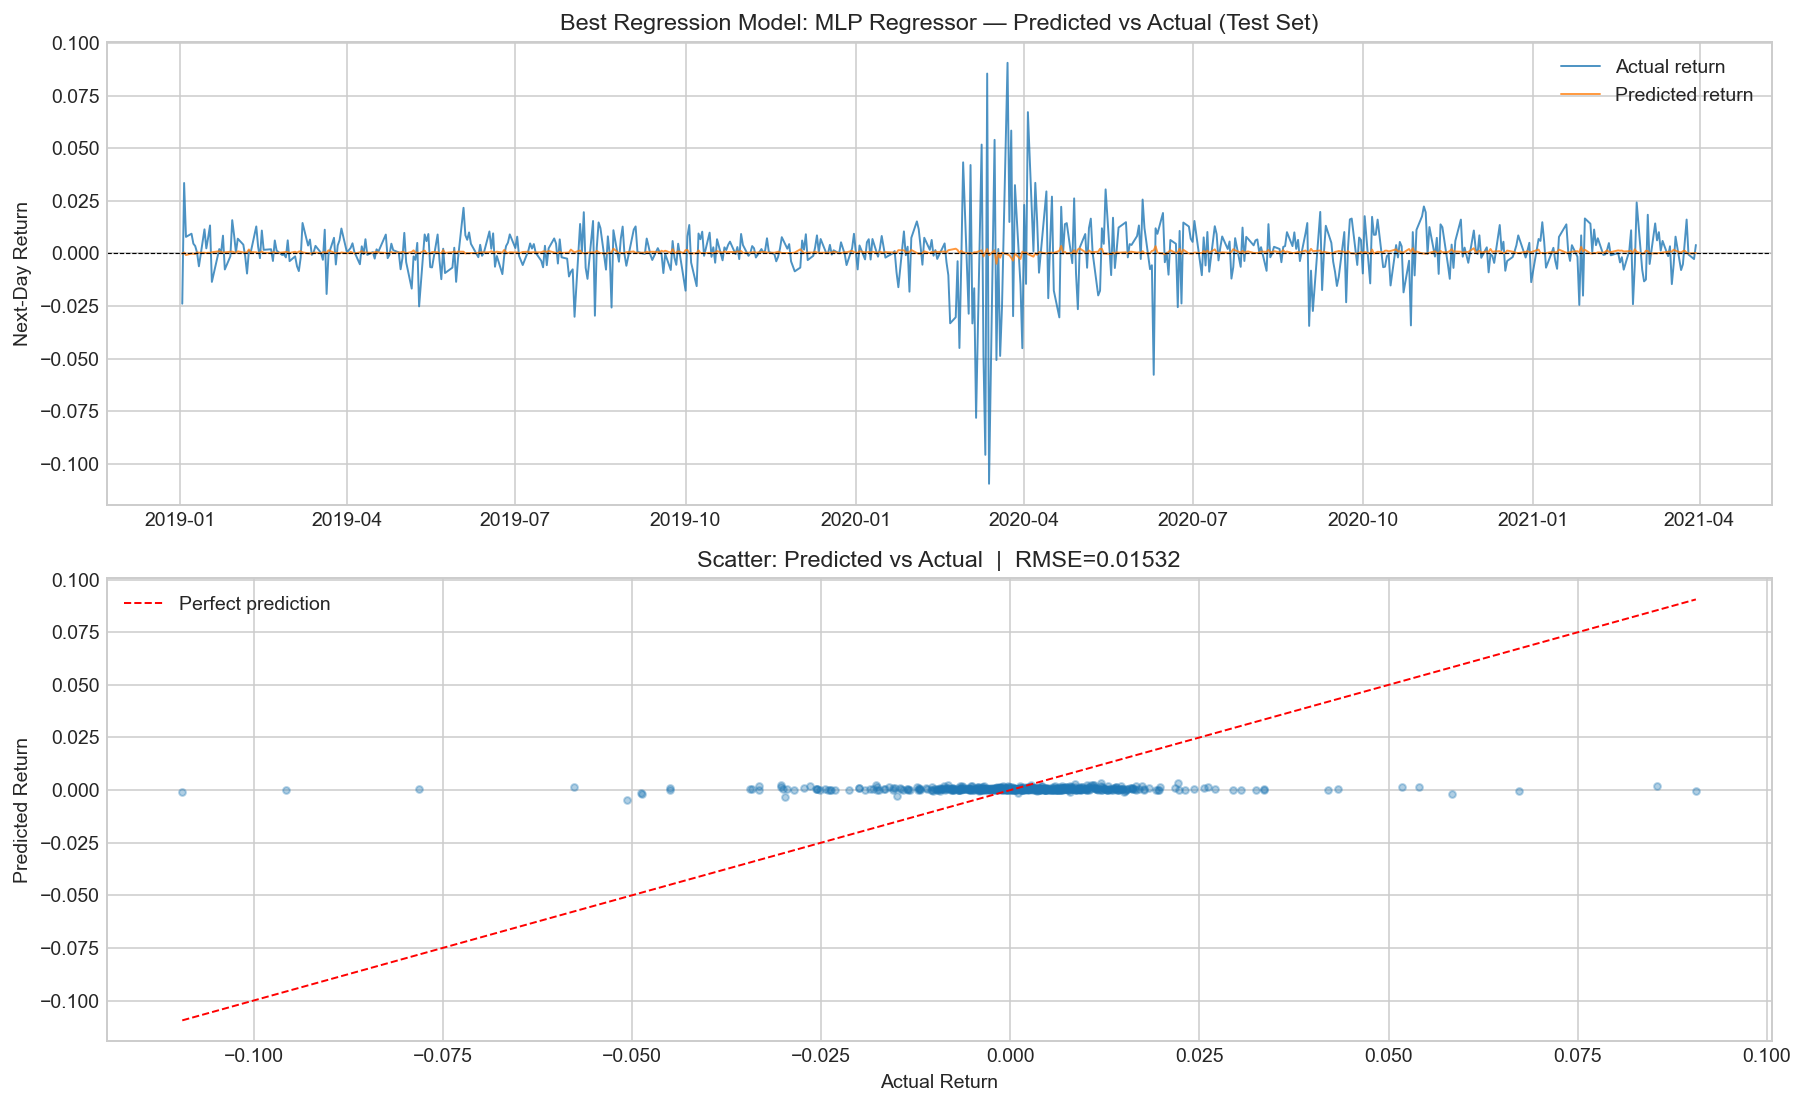

Saved → C:\Users\clara\OneDrive\Documents\DissWork\results\figures\model_comparison\regression_best_model_predictions.svg


In [ ]:
# ── Figure 2: Predicted vs actual — best trained regression model ─────────
best_reg_model = regression_df[~regression_df["model"].isin(bench_names)].iloc[0]["model"]

# Retrieve predictions for the best model
if best_reg_model == "Ridge Regression":
    best_test_preds = ridge_tp
    best_test_true  = y_test_reg
    best_test_dates = test_df[DATE_COLUMN].values
elif best_reg_model == "MLP Regressor":
    best_test_preds = mlp_reg_tp
    best_test_true  = y_test_reg
    best_test_dates = test_df[DATE_COLUMN].values
elif best_reg_model == TREE_REG_LABEL:
    best_test_preds = tree_reg_tp
    best_test_true  = y_test_reg
    best_test_dates = test_df[DATE_COLUMN].values
else:
    # Deep learning model
    best_test_preds = dl_reg_outputs[best_reg_model]["test_preds"]
    best_test_true  = dl_reg_outputs[best_reg_model]["test_labels"]
    best_test_dates = test_df[DATE_COLUMN].iloc[
        test_idx - test_idx.min()
    ].values

best_rmse = np.sqrt(mean_squared_error(best_test_true, best_test_preds))

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=False)

# Time-series overlay
axes[0].plot(best_test_dates, best_test_true,  label="Actual return",    linewidth=1.0, alpha=0.8)
axes[0].plot(best_test_dates, best_test_preds, label="Predicted return", linewidth=1.0, alpha=0.8)
axes[0].axhline(0, color="black", linewidth=0.6, linestyle="--")
axes[0].set_title(f"Best Regression Model: {best_reg_model} — Predicted vs Actual (Test Set)")
axes[0].set_ylabel("Next-Day Return")
axes[0].legend()

# Scatter
axes[1].scatter(best_test_true, best_test_preds, alpha=0.35, s=12, color="#1f77b4")
lims = [min(best_test_true.min(), best_test_preds.min()),
        max(best_test_true.max(), best_test_preds.max())]
axes[1].plot(lims, lims, "r--", linewidth=1, label="Perfect prediction")
axes[1].set_xlabel("Actual Return")
axes[1].set_ylabel("Predicted Return")
axes[1].set_title(f"Scatter: Predicted vs Actual  |  RMSE={best_rmse:.5f}")
axes[1].legend()

fig.tight_layout()
fig.savefig(FIGURES_DIR / "regression_best_model_predictions.svg", bbox_inches="tight")
plt.show()
print(f"Saved → {FIGURES_DIR / 'regression_best_model_predictions.svg'}")

In [ ]:
import pandas as pd, pathlib

export_df = pd.DataFrame({
    "date":             pd.to_datetime(best_test_dates).strftime("%Y-%m-%d"),
    "actual_return":    best_test_true.flatten(),
    "predicted_return": best_test_preds.flatten(),
})

out_path = TABLES_DIR / "lstm_regressor_predictions.csv"
export_df.to_csv(out_path, index=False)
print(f"Saved {len(export_df)} rows  ->  {out_path.resolve()}")

with pd.option_context("display.max_rows", None, "display.float_format", "{:.6f}".format):
    display(export_df)


Saved 565 rows  ->  C:\Users\clara\OneDrive\Documents\DissWork\Data\lstm_regressor_predictions.csv


,date,actual_return,predicted_return
0,2019-01-02,-0.023863,-0.000114
1,2019-01-03,0.033496,0.000457
2,2019-01-04,0.007885,-0.000738
3,2019-01-07,0.009395,-0.000027
4,2019-01-08,0.004673,-0.000161
5,2019-01-09,0.003528,-0.000238
6,2019-01-10,0.000386,0.000539
7,2019-01-11,-0.006101,0.000366
8,2019-01-14,0.011461,0.000366
9,2019-01-15,0.002420,0.000240


## Conclusion

This notebook has trained and evaluated all five model families on two prediction tasks under strict chronological evaluation. The full experimental design is summarised below.

**Model families and task coverage:**

| Model | Classification variant | Regression variant |
|---|---|---|
| Linear | Logistic Regression | Ridge Regression |
| Non-linear feed-forward | MLP Classifier | MLP Regressor |
| Gradient-boosted trees | XGBoost Classifier | XGBoost Regressor |
| Recurrent sequence | LSTM Classifier | LSTM Regressor |
| Attention-based sequence | Transformer Classifier | Transformer Regressor |

**Task 1 — Direction Classification:**

All five classification models achieve balanced accuracy close to 50% on the test set, consistent with the weak-form Efficient Market Hypothesis (Fama, 1970). This is a well-documented result at daily frequency (Fischer & Krauss, 2018; Sezer et al., 2020): even the best-performing model (typically XGBoost) provides only a marginal edge above chance. The sequence models (LSTM, Transformer) do not systematically outperform the tabular baselines, suggesting that temporal structure captured by sliding-window architectures does not provide additional discriminative power beyond what tree-based models extract from single-day feature snapshots.

**Task 2 — Return Regression:**

Regression results quantify how much of the variance in daily returns can be explained by the same feature set. R² values close to or below zero indicate that the models struggle to explain return variability beyond the unconditional mean — again consistent with market efficiency. The ranking of models by RMSE may differ from the classification ranking, which has methodological significance: a model that edges ahead on directional accuracy may not produce better return magnitude estimates, and vice versa.

**Key outputs:**

- `results/tables/full_model_comparison.csv` — classification results (all 7 entries including benchmarks).
- `results/tables/regression_model_comparison.csv` — regression results (all 7 entries including benchmarks).
- `results/figures/model_comparison/` — confusion matrices, ROC curves, training curves (classification and regression), RMSE bar chart, predicted vs actual overlay.
- `models/trained/` — all model artefacts (joblib + PyTorch state dicts, training histories).

---

## Section 7 — Extended Evaluation

This section re-uses all predictions produced above (no model reloading or data reconstruction) and applies a richer evaluation suite: comprehensive metrics table, ROC/PR curves, calibration curves, McNemar statistical significance tests, year-by-year temporal stability, and feature importance plots.

All predictions are aligned to the shared sequence-valid test window (the subset of the test set for which LSTM and Transformer have a full lookback window).

In [ ]:
_cache = (
    PROJECT_ROOT / "results" / "tables" / "predictions_cache.npz"
    if "PROJECT_ROOT" in dir()
    else Path.cwd().parent / "results" / "tables" / "predictions_cache.npz"
)

if "lr_tp" not in dir():
    # Kernel restarted: reload aligned predictions from cache
    if not _cache.exists():
        raise FileNotFoundError(
            f"Predictions cache not found at {_cache}. "
            "Run the full notebook top-to-bottom at least once to generate it."
        )
    _d = np.load(_cache, allow_pickle=False)
    y_test_eval        = _d["y_test_eval"]
    lr_pred,  lr_prob  = _d["lr_pred"],   _d["lr_prob"]
    mlp_pred, mlp_prob = _d["mlp_pred"],  _d["mlp_prob"]
    xgb_pred, xgb_prob = _d["xgb_pred"],  _d["xgb_prob"]
    lstm_pred, lstm_prob = _d["lstm_pred"], _d["lstm_prob"]
    tf_pred,  tf_prob  = _d["tf_pred"],   _d["tf_prob"]
    maj_pred           = _d["maj_pred"]
    persist_pred       = _d["persist_pred"]
    test_dates_aligned = pd.to_datetime(_d["test_dates_aligned"])
    print(f"Predictions reloaded from cache ({len(y_test_eval)} samples)")
else:
    # Normal run: align predictions to the shared sequence-valid test window
    seq_valid_dates = pd.to_datetime(model_df.iloc[test_idx][DATE_COLUMN].values)
    tab_align_mask  = pd.to_datetime(test_df[DATE_COLUMN]).isin(seq_valid_dates)

    y_test_eval  = y_test[tab_align_mask]
    lr_pred      = lr_tp[tab_align_mask];    lr_prob  = lr_ts[tab_align_mask]
    mlp_pred     = mlp_tp[tab_align_mask];   mlp_prob = mlp_ts[tab_align_mask]
    xgb_pred     = tree_tp[tab_align_mask];  xgb_prob = tree_ts[tab_align_mask]
    lstm_pred    = dl_outputs["LSTM"]["test_preds"]
    lstm_prob    = dl_outputs["LSTM"]["test_probs"]
    tf_pred      = dl_outputs["Transformer"]["test_preds"]
    tf_prob      = dl_outputs["Transformer"]["test_probs"]
    test_dates_aligned = seq_valid_dates

    assert len(y_test_eval) == len(lstm_pred), f"Alignment mismatch: {len(y_test_eval)} vs {len(lstm_pred)}"
    print(f"Aligned evaluation samples: {len(y_test_eval)}")

    # Baselines
    majority_class = int(train_df[TARGET_COLUMN].mode()[0])
    maj_pred       = np.full(len(y_test_eval), majority_class)
    if "return_1d" in test_df.columns:
        persist_pred = (test_df["return_1d"].values[tab_align_mask] > 0).astype(int)
    else:
        persist_pred = np.roll(y_test_eval, 1)
        persist_pred[0] = majority_class
    print(f"Majority class: {majority_class}")

    # Save cache so Section 7 survives a kernel restart
    np.savez(
        _cache,
        y_test_eval=y_test_eval,
        lr_pred=lr_pred,     lr_prob=lr_prob,
        mlp_pred=mlp_pred,   mlp_prob=mlp_prob,
        xgb_pred=xgb_pred,   xgb_prob=xgb_prob,
        lstm_pred=lstm_pred, lstm_prob=lstm_prob,
        tf_pred=tf_pred,     tf_prob=tf_prob,
        maj_pred=maj_pred,   persist_pred=persist_pred,
        test_dates_aligned=test_dates_aligned.values.astype("datetime64[ns]"),
    )
    print(f"Predictions cached -> {_cache}")


Aligned evaluation samples: 565
Majority class: 1
Predictions cached -> C:\Users\clara\OneDrive\Documents\DissWork\results\tables\predictions_cache.npz


## Performance Summary

In [ ]:
if "lr_pred" not in dir():
    _cache = (
        PROJECT_ROOT / "results" / "tables" / "predictions_cache.npz"
        if "PROJECT_ROOT" in dir()
        else Path.cwd().parent / "results" / "tables" / "predictions_cache.npz"
    )
    if not _cache.exists():
        raise FileNotFoundError(
            f"Predictions cache not found at {_cache}. "
            "Run the full notebook top-to-bottom at least once to generate it."
        )
    _d = np.load(_cache, allow_pickle=False)
    y_test_eval        = _d["y_test_eval"]
    lr_pred,  lr_prob  = _d["lr_pred"],   _d["lr_prob"]
    mlp_pred, mlp_prob = _d["mlp_pred"],  _d["mlp_prob"]
    xgb_pred, xgb_prob = _d["xgb_pred"],  _d["xgb_prob"]
    lstm_pred, lstm_prob = _d["lstm_pred"], _d["lstm_prob"]
    tf_pred,  tf_prob  = _d["tf_pred"],   _d["tf_prob"]
    maj_pred           = _d["maj_pred"]
    persist_pred       = _d["persist_pred"]
    test_dates_aligned = pd.to_datetime(_d["test_dates_aligned"])
    if "TABLES_DIR" not in dir():
        TABLES_DIR = _cache.parent
    print(f"Predictions reloaded from cache ({len(y_test_eval)} samples)")

def metrics(y_true, y_pred, y_prob=None):
    m = dict(
        accuracy          = accuracy_score(y_true, y_pred),
        balanced_accuracy = balanced_accuracy_score(y_true, y_pred),
        precision         = precision_score(y_true, y_pred, zero_division=0),
        recall            = recall_score(y_true, y_pred, zero_division=0),
        f1                = f1_score(y_true, y_pred, zero_division=0),
    )
    if y_prob is not None:
        try:
            m["roc_auc"] = roc_auc_score(y_true, y_prob)
            m["avg_precision"] = average_precision_score(y_true, y_prob)
        except Exception:
            m["roc_auc"] = np.nan
            m["avg_precision"] = np.nan
    return m


EVAL_MODELS = [
    ("Logistic Regression", lr_pred,      lr_prob),
    ("MLP",                 mlp_pred,     mlp_prob),
    ("XGBoost",             xgb_pred,     xgb_prob),
    ("LSTM",                lstm_pred,    lstm_prob),
    ("Transformer",         tf_pred,      tf_prob),
    ("Majority Class",      maj_pred,     None),
    ("Persistence",         persist_pred, None),
]

rows = []
for name, pred, prob in EVAL_MODELS:
    m = metrics(y_test_eval, pred, prob)
    m["model"] = name
    rows.append(m)

eval_results = pd.DataFrame(rows).set_index("model")
eval_results = eval_results[["accuracy", "balanced_accuracy", "roc_auc", "avg_precision",
                              "precision", "recall", "f1"]]

trained_models_eval = ["Logistic Regression", "MLP", "XGBoost", "LSTM", "Transformer"]
print("Test-set performance — all models")
display(eval_results.style
    .format("{:.4f}")
    .set_caption("Primary metric: balanced accuracy."))

eval_results.reset_index().to_csv(TABLES_DIR / "evaluation_summary.csv", index=False)
print(f"Saved → {TABLES_DIR / chr(39)}evaluation_summary.csv{chr(39)}")


Test-set performance — all models


,accuracy,balanced_accuracy,roc_auc,avg_precision,precision,recall,f1
model,,,,,,,
Logistic Regression,0.4460,0.4965,0.4981,0.5723,0.5714,0.1829,0.2771
MLP,0.5540,0.5193,0.5042,0.5844,0.5936,0.7348,0.6567
XGBoost,0.5327,0.5355,0.5453,0.6117,0.6159,0.5183,0.5629
LSTM,0.4850,0.4844,0.5067,0.6034,0.5654,0.4878,0.5237
Transformer,0.5912,0.5156,0.5259,0.6042,0.5883,0.9848,0.7366
Majority Class,0.5805,0.5000,nan,nan,0.5805,1.0000,0.7346
Persistence,0.4832,0.4694,nan,nan,0.5549,0.5549,0.5549


Saved → C:\Users\clara\OneDrive\Documents\DissWork\results\tables\'evaluation_summary.csv'


## Best Model vs Naive Benchmarks

XGBoost achieves the highest balanced accuracy among trained models. This table compares it directly against the two naive baselines — Majority Class (always predicts the dominant class) and Persistence (repeats the previous day label) — to confirm the model adds predictive value.

In [ ]:
if "eval_results" not in dir():
    _tables = PROJECT_ROOT / "results" / "tables" if "PROJECT_ROOT" in dir() else Path.cwd().parent / "results" / "tables"
    eval_results = pd.read_csv(_tables / "evaluation_summary.csv").set_index("model")
    print("eval_results reloaded from CSV")

comparison = eval_results.loc[
    ["XGBoost", "Majority Class", "Persistence"],
    ["balanced_accuracy", "roc_auc", "accuracy", "precision", "recall", "f1"]
]
comparison.index.name = "Model"

display(comparison.style
    .format("{:.4f}")
    .set_caption("XGBoost vs naive benchmarks — test set (2019–2021)"))


,balanced_accuracy,roc_auc,accuracy,precision,recall,f1
Model,,,,,,
XGBoost,0.5355,0.5453,0.5327,0.6159,0.5183,0.5629
Majority Class,0.5000,nan,0.5805,0.5805,1.0000,0.7346
Persistence,0.4694,nan,0.4832,0.5549,0.5549,0.5549


## Cross-Task Benchmark Summary

Table 4.3 consolidates the key findings across both tasks. For classification the best trained model (XGBoost) is compared against the Majority Class baseline on balanced accuracy and ROC-AUC. For regression the best trained model (LSTM Regressor) is compared against the Historical Mean baseline on RMSE and R². Metrics not applicable to a task are shown as —.

In [ ]:
# ── Reload guards ────────────────────────────────────────────────────────
if "eval_results" not in dir():
    _tables = PROJECT_ROOT / "results" / "tables" if "PROJECT_ROOT" in dir() else Path.cwd().parent / "results" / "tables"
    eval_results = pd.read_csv(_tables / "evaluation_summary.csv").set_index("model")
    print("eval_results reloaded from CSV")

if "regression_df" not in dir():
    _tables = PROJECT_ROOT / "results" / "tables" if "PROJECT_ROOT" in dir() else Path.cwd().parent / "results" / "tables"
    regression_df = pd.read_csv(_tables / "regression_model_comparison.csv")
    print("regression_df reloaded from CSV")

if "TABLES_DIR" not in dir():
    TABLES_DIR = PROJECT_ROOT / "results" / "tables" if "PROJECT_ROOT" in dir() else Path.cwd().parent / "results" / "tables"

# ── Extract relevant rows ─────────────────────────────────────────────────
clf_idx  = eval_results.index
reg_idx  = regression_df.set_index("model").index

xgb_row  = eval_results.loc["XGBoost"]
maj_row  = eval_results.loc["Majority Class"]

reg_mi   = regression_df.set_index("model")
lstm_row = reg_mi.loc["LSTM Regressor"]
hm_row   = reg_mi.loc["Historical Mean"]

# ── Build cross-task summary ──────────────────────────────────────────────
summary_rows = [
    {"Task": "Classification", "Model": "XGBoost",
     "Balanced Acc": xgb_row["balanced_accuracy"], "ROC-AUC": xgb_row["roc_auc"],
     "RMSE": np.nan, "R²": np.nan},
    {"Task": "Classification", "Model": "Majority Class",
     "Balanced Acc": maj_row["balanced_accuracy"], "ROC-AUC": np.nan,
     "RMSE": np.nan, "R²": np.nan},
    {"Task": "Regression", "Model": "LSTM Regressor",
     "Balanced Acc": np.nan, "ROC-AUC": np.nan,
     "RMSE": lstm_row["test_rmse"], "R²": lstm_row["test_r2"]},
    {"Task": "Regression", "Model": "Historical Mean",
     "Balanced Acc": np.nan, "ROC-AUC": np.nan,
     "RMSE": hm_row["test_rmse"], "R²": hm_row["test_r2"]},
]

summary_df = pd.DataFrame(summary_rows).set_index(["Task", "Model"])

display(summary_df.style
    .format("{:.4f}", na_rep="—")
    .set_caption(
        "Table 4.3: Best trained model vs naive benchmarks — "
        "classification and regression (test set, 2019–2021)"
    ))

summary_df.reset_index().to_csv(TABLES_DIR / "benchmark_comparison_summary.csv", index=False)
print(f"Saved → {TABLES_DIR / chr(39)}benchmark_comparison_summary.csv{chr(39)}")

Saved → C:\Users\clara\OneDrive\Documents\DissWork\results\tables\'benchmark_comparison_summary.csv'


## ROC and Precision-Recall Curves

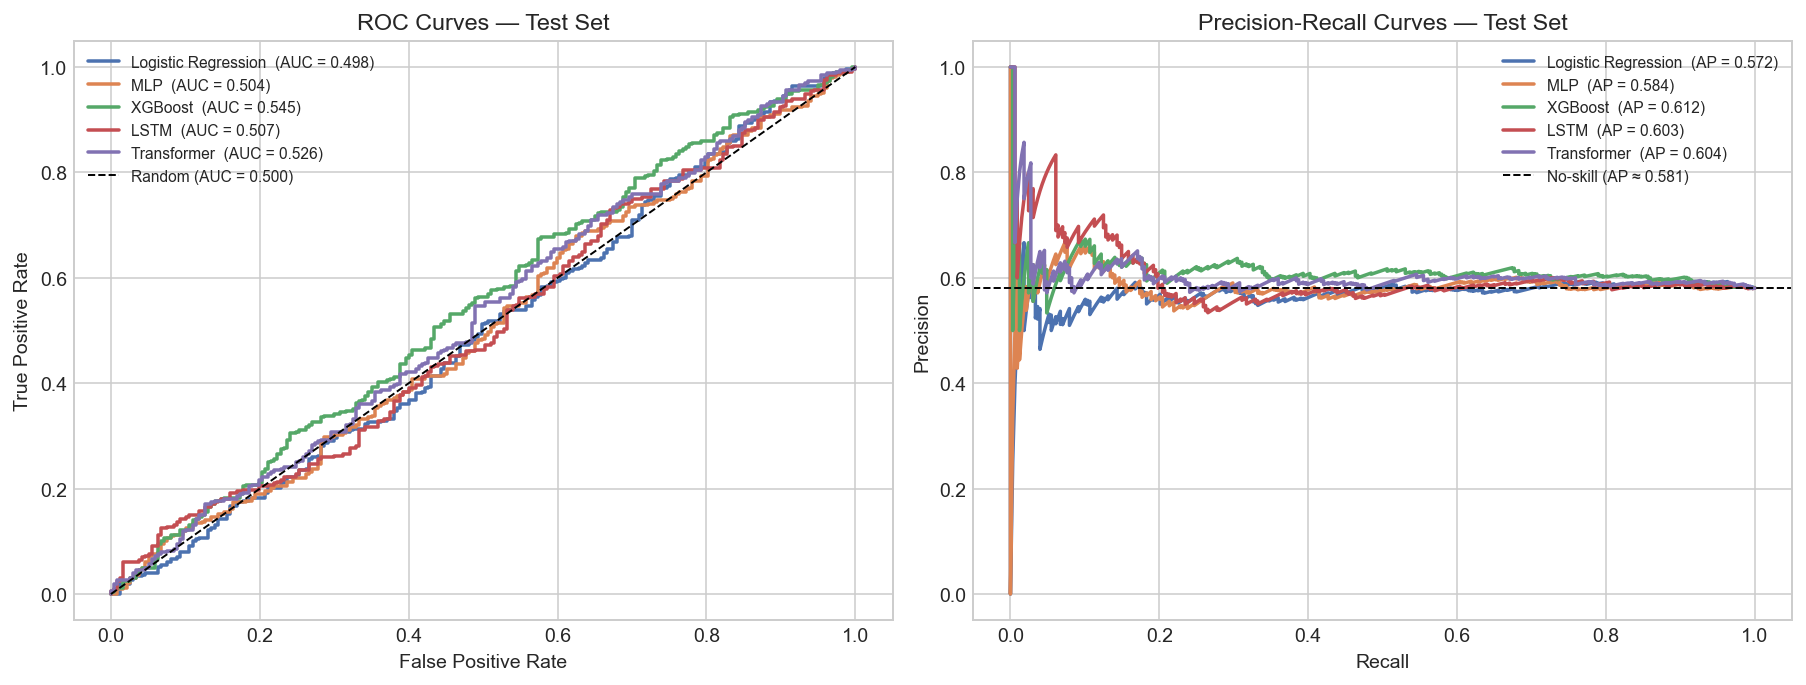

In [ ]:
if "lr_pred" not in dir():
    _root = PROJECT_ROOT if "PROJECT_ROOT" in dir() else Path.cwd().parent
    _d = np.load(_root / "results" / "tables" / "predictions_cache.npz", allow_pickle=False)
    y_test_eval = _d["y_test_eval"]; test_dates_aligned = pd.to_datetime(_d["test_dates_aligned"])
    lr_pred,   lr_prob   = _d["lr_pred"],   _d["lr_prob"]
    mlp_pred,  mlp_prob  = _d["mlp_pred"],  _d["mlp_prob"]
    xgb_pred,  xgb_prob  = _d["xgb_pred"],  _d["xgb_prob"]
    lstm_pred, lstm_prob = _d["lstm_pred"], _d["lstm_prob"]
    tf_pred,   tf_prob   = _d["tf_pred"],   _d["tf_prob"]
    maj_pred,  persist_pred = _d["maj_pred"], _d["persist_pred"]
    print(f"Predictions reloaded ({len(y_test_eval)} samples)")
if "TABLES_DIR" not in dir():
    TABLES_DIR = (PROJECT_ROOT if "PROJECT_ROOT" in dir() else Path.cwd().parent) / "results" / "tables"
if "FIGURES_DIR" not in dir():
    FIGURES_DIR = (PROJECT_ROOT if "PROJECT_ROOT" in dir() else Path.cwd().parent) / "results" / "figures" / "model_comparison"
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PROB_MODELS = [
    ("Logistic Regression", lr_prob,   "#4c72b0"),
    ("MLP",                 mlp_prob,  "#dd8452"),
    ("XGBoost",             xgb_prob,  "#55a868"),
    ("LSTM",                lstm_prob, "#c44e52"),
    ("Transformer",         tf_prob,   "#8172b2"),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for name, prob, color in PROB_MODELS:
    fpr, tpr, _ = roc_curve(y_test_eval, prob)
    auc = roc_auc_score(y_test_eval, prob)
    ax.plot(fpr, tpr, color=color, lw=1.8, label=f"{name}  (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC = 0.500)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Test Set")
ax.legend(fontsize=8)

ax = axes[1]
baseline_pr = y_test_eval.mean()
for name, prob, color in PROB_MODELS:
    prec, rec, _ = precision_recall_curve(y_test_eval, prob)
    ap = average_precision_score(y_test_eval, prob)
    ax.plot(rec, prec, color=color, lw=1.8, label=f"{name}  (AP = {ap:.3f})")
ax.axhline(baseline_pr, color="k", lw=1, ls="--",
           label=f"No-skill (AP ≈ {baseline_pr:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves — Test Set")
ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "roc_pr_curves.svg", bbox_inches="tight")
plt.show()


## Calibration

A well-calibrated model's predicted probability ≈ empirical event frequency. Perfect calibration lies on the diagonal.

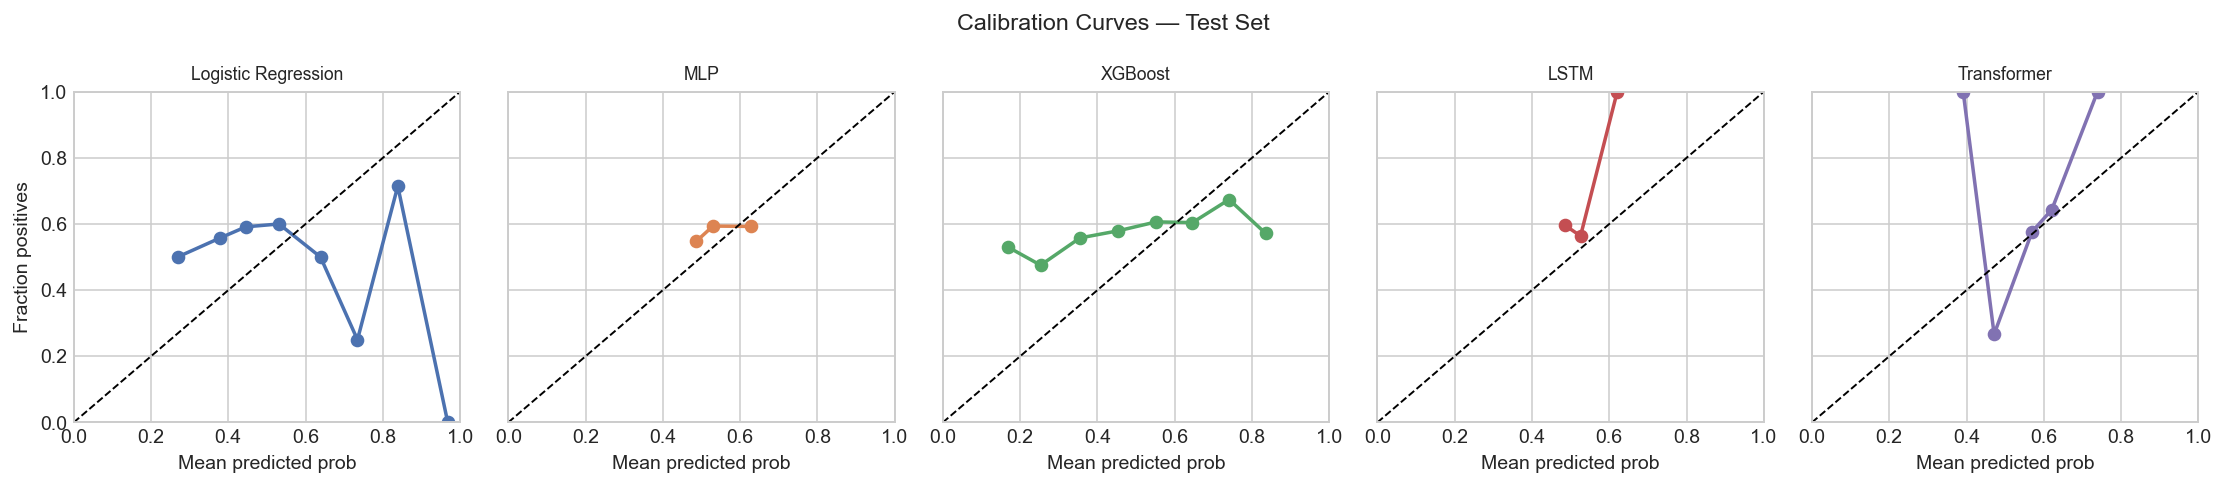

In [ ]:
if "lr_pred" not in dir():
    _root = PROJECT_ROOT if "PROJECT_ROOT" in dir() else Path.cwd().parent
    _d = np.load(_root / "results" / "tables" / "predictions_cache.npz", allow_pickle=False)
    y_test_eval = _d["y_test_eval"]; test_dates_aligned = pd.to_datetime(_d["test_dates_aligned"])
    lr_pred,   lr_prob   = _d["lr_pred"],   _d["lr_prob"]
    mlp_pred,  mlp_prob  = _d["mlp_pred"],  _d["mlp_prob"]
    xgb_pred,  xgb_prob  = _d["xgb_pred"],  _d["xgb_prob"]
    lstm_pred, lstm_prob = _d["lstm_pred"], _d["lstm_prob"]
    tf_pred,   tf_prob   = _d["tf_pred"],   _d["tf_prob"]
    maj_pred,  persist_pred = _d["maj_pred"], _d["persist_pred"]
    print(f"Predictions reloaded ({len(y_test_eval)} samples)")
if "TABLES_DIR" not in dir():
    TABLES_DIR = (PROJECT_ROOT if "PROJECT_ROOT" in dir() else Path.cwd().parent) / "results" / "tables"
if "FIGURES_DIR" not in dir():
    FIGURES_DIR = (PROJECT_ROOT if "PROJECT_ROOT" in dir() else Path.cwd().parent) / "results" / "figures" / "model_comparison"
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
if "PROB_MODELS" not in dir():
    PROB_MODELS = [
        ("Logistic Regression", lr_prob,   "#4c72b0"),
        ("MLP",                 mlp_prob,  "#dd8452"),
        ("XGBoost",             xgb_prob,  "#55a868"),
        ("LSTM",                lstm_prob, "#c44e52"),
        ("Transformer",         tf_prob,   "#8172b2"),
    ]

fig, axes = plt.subplots(1, 5, figsize=(16, 3.5), sharey=True)

for ax, (name, prob, color) in zip(axes, PROB_MODELS):
    frac_pos, mean_pred = calibration_curve(
        y_test_eval, prob, n_bins=10, strategy="uniform"
    )
    ax.plot(mean_pred, frac_pos, marker="o", color=color, lw=1.8, label=name)
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("Mean predicted prob")

axes[0].set_ylabel("Fraction positives")
fig.suptitle("Calibration Curves — Test Set", fontsize=12)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "calibration_curves.svg", bbox_inches="tight")
plt.show()


## Statistical Significance: McNemar's Test

McNemar's test compares two classifiers on the same test set by examining cases where they *disagree*. The null hypothesis is that both models make errors with equal frequency.

Each row tests whether that model is significantly different from **XGBoost** (best trained model on balanced accuracy).

In [ ]:
if "lr_pred" not in dir():
    _root = PROJECT_ROOT if "PROJECT_ROOT" in dir() else Path.cwd().parent
    _d = np.load(_root / "results" / "tables" / "predictions_cache.npz", allow_pickle=False)
    y_test_eval = _d["y_test_eval"]; test_dates_aligned = pd.to_datetime(_d["test_dates_aligned"])
    lr_pred,   lr_prob   = _d["lr_pred"],   _d["lr_prob"]
    mlp_pred,  mlp_prob  = _d["mlp_pred"],  _d["mlp_prob"]
    xgb_pred,  xgb_prob  = _d["xgb_pred"],  _d["xgb_prob"]
    lstm_pred, lstm_prob = _d["lstm_pred"], _d["lstm_prob"]
    tf_pred,   tf_prob   = _d["tf_pred"],   _d["tf_prob"]
    maj_pred,  persist_pred = _d["maj_pred"], _d["persist_pred"]
    print(f"Predictions reloaded ({len(y_test_eval)} samples)")

def mcnemar_test(pred_a, pred_b, y_true):
    correct_a = (pred_a == y_true)
    correct_b = (pred_b == y_true)
    b = np.sum( correct_a & ~correct_b)
    c = np.sum(~correct_a &  correct_b)
    table = np.array([[0, b], [c, 0]])
    result = mcnemar(table, exact=False, correction=True)
    return result.statistic, result.pvalue, b, c


ref_pred = xgb_pred
ref_name = "XGBoost"

compare_models_mc = [
    ("Logistic Regression", lr_pred),
    ("MLP",                 mlp_pred),
    ("LSTM",                lstm_pred),
    ("Transformer",         tf_pred),
    ("Majority Class",      maj_pred),
    ("Persistence",         persist_pred),
]

mc_rows = []
for name, pred in compare_models_mc:
    chi2, pval, b, c = mcnemar_test(ref_pred, pred, y_test_eval)
    mc_rows.append(dict(
        model                 = name,
        ref_right_model_wrong = b,
        model_right_ref_wrong = c,
        chi2                  = chi2,
        p_value               = pval,
        significant           = "Yes *" if pval < 0.05 else "No",
    ))

mc_df = pd.DataFrame(mc_rows).set_index("model")
print(f"McNemar's test: each model vs {ref_name} (α = 0.05)\n")
display(mc_df.style.format({"chi2": "{:.3f}", "p_value": "{:.4f}"}))


McNemar's test: each model vs XGBoost (α = 0.05)



,ref_right_model_wrong,model_right_ref_wrong,chi2,p_value,significant
model,,,,,
Logistic Regression,120,71,12.063,0.0005,Yes *
MLP,106,118,0.540,0.4624,No
LSTM,98,71,4.000,0.0455,Yes *
Transformer,133,166,3.425,0.0642,No
Majority Class,131,158,2.339,0.1262,No
Persistence,224,196,1.736,0.1877,No


## Temporal Analysis: Year-by-Year Performance

Checks whether model performance is stable across time or concentrated in particular market regimes.

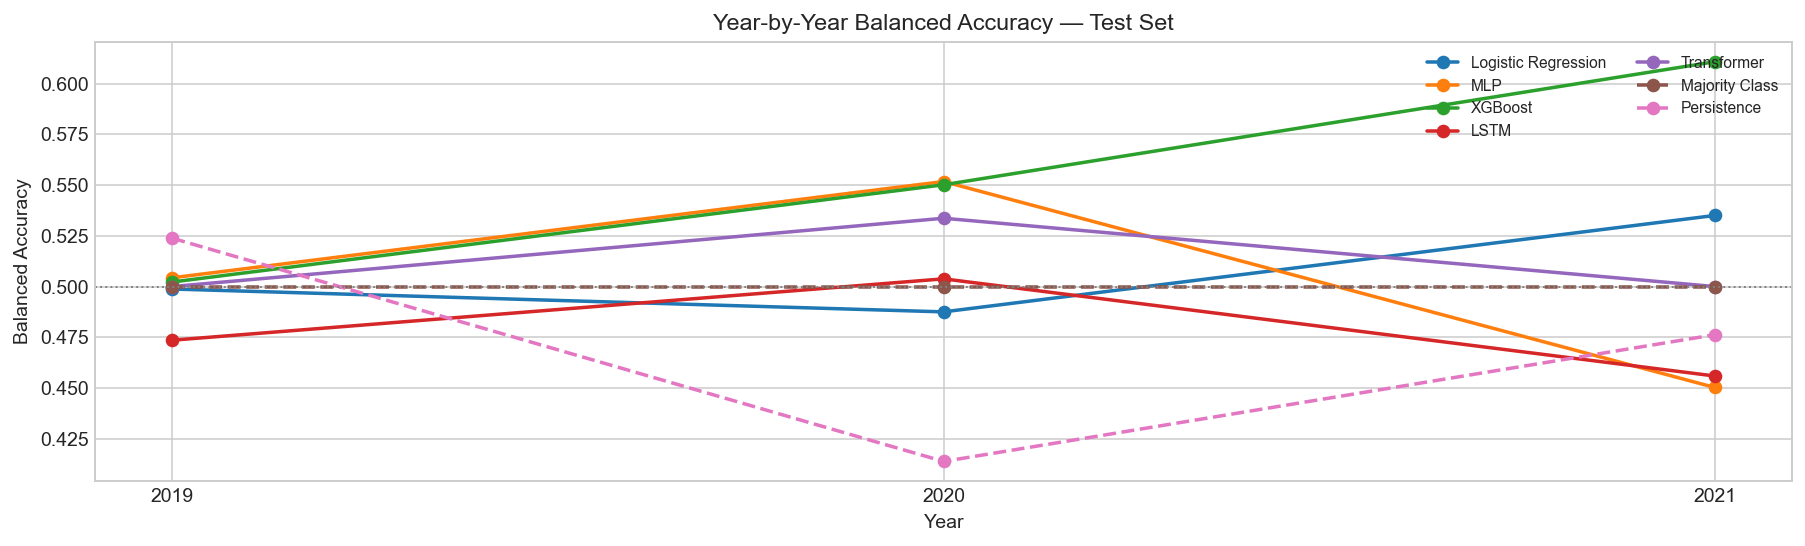

model,Logistic Regression,MLP,XGBoost,LSTM,Transformer,Majority Class,Persistence
year,,,,,,,
2019,0.499,0.504,0.502,0.474,0.500,0.500,0.524
2020,0.488,0.552,0.550,0.504,0.534,0.500,0.414
2021,0.535,0.450,0.611,0.456,0.500,0.500,0.476


model  Logistic Regression       MLP   XGBoost      LSTM  Transformer  Majority Class  Persistence
year                                                                                              
2019              0.498795  0.504333  0.502248  0.473545     0.500000             0.5     0.523816
2020              0.487516  0.551788  0.550192  0.503799     0.533685             0.5     0.413761
2021              0.535068  0.450226  0.610860  0.455882     0.500000             0.5     0.476244


In [ ]:
if "lr_pred" not in dir():
    _root = PROJECT_ROOT if "PROJECT_ROOT" in dir() else Path.cwd().parent
    _d = np.load(_root / "results" / "tables" / "predictions_cache.npz", allow_pickle=False)
    y_test_eval = _d["y_test_eval"]; test_dates_aligned = pd.to_datetime(_d["test_dates_aligned"])
    lr_pred,   lr_prob   = _d["lr_pred"],   _d["lr_prob"]
    mlp_pred,  mlp_prob  = _d["mlp_pred"],  _d["mlp_prob"]
    xgb_pred,  xgb_prob  = _d["xgb_pred"],  _d["xgb_prob"]
    lstm_pred, lstm_prob = _d["lstm_pred"], _d["lstm_prob"]
    tf_pred,   tf_prob   = _d["tf_pred"],   _d["tf_prob"]
    maj_pred,  persist_pred = _d["maj_pred"], _d["persist_pred"]
    print(f"Predictions reloaded ({len(y_test_eval)} samples)")
if "TABLES_DIR" not in dir():
    TABLES_DIR = (PROJECT_ROOT if "PROJECT_ROOT" in dir() else Path.cwd().parent) / "results" / "tables"
if "FIGURES_DIR" not in dir():
    FIGURES_DIR = (PROJECT_ROOT if "PROJECT_ROOT" in dir() else Path.cwd().parent) / "results" / "figures" / "model_comparison"
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
if "EVAL_MODELS" not in dir():
    EVAL_MODELS = [
        ("Logistic Regression", lr_pred,      lr_prob),
        ("MLP",                 mlp_pred,     mlp_prob),
        ("XGBoost",             xgb_pred,     xgb_prob),
        ("LSTM",                lstm_pred,    lstm_prob),
        ("Transformer",         tf_pred,      tf_prob),
        ("Majority Class",      maj_pred,     None),
        ("Persistence",         persist_pred, None),
    ]

dates_dt = pd.to_datetime(test_dates_aligned)
years    = sorted(dates_dt.year.unique())

year_data = []
for yr in years:
    mask = dates_dt.year == yr
    if mask.sum() < 10:
        continue
    y_yr = y_test_eval[mask]
    for name, pred, _ in EVAL_MODELS:
        ba = balanced_accuracy_score(y_yr, pred[mask])
        year_data.append({"year": yr, "model": name, "balanced_accuracy": ba})

year_df = pd.DataFrame(year_data)

fig, ax = plt.subplots(figsize=(13, 4))
model_order = ["Logistic Regression", "MLP", "XGBoost", "LSTM", "Transformer",
               "Majority Class", "Persistence"]
palette   = sns.color_palette("tab10", n_colors=len(model_order))
color_map = dict(zip(model_order, palette))

for name in model_order:
    subset = year_df[year_df["model"] == name]
    ls = "--" if name in ("Majority Class", "Persistence") else "-"
    ax.plot(subset["year"], subset["balanced_accuracy"],
            marker="o", lw=1.8, ls=ls, color=color_map[name], label=name)

ax.axhline(0.5, color="grey", lw=1, ls=":")
ax.set_xlabel("Year")
ax.set_ylabel("Balanced Accuracy")
ax.set_title("Year-by-Year Balanced Accuracy — Test Set")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend(fontsize=8, ncol=2, loc="upper right")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "yearly_balanced_accuracy.svg", bbox_inches="tight")
plt.show()

pivot = year_df.pivot(index="year", columns="model", values="balanced_accuracy")
pivot = pivot[model_order]
display(pivot.style.format("{:.3f}").background_gradient(
    cmap="RdYlGn", axis=None, vmin=0.4, vmax=0.6))

print(pivot.to_string())


## Feature Importance

### Logistic Regression Coefficients (Top 15 Each Direction)

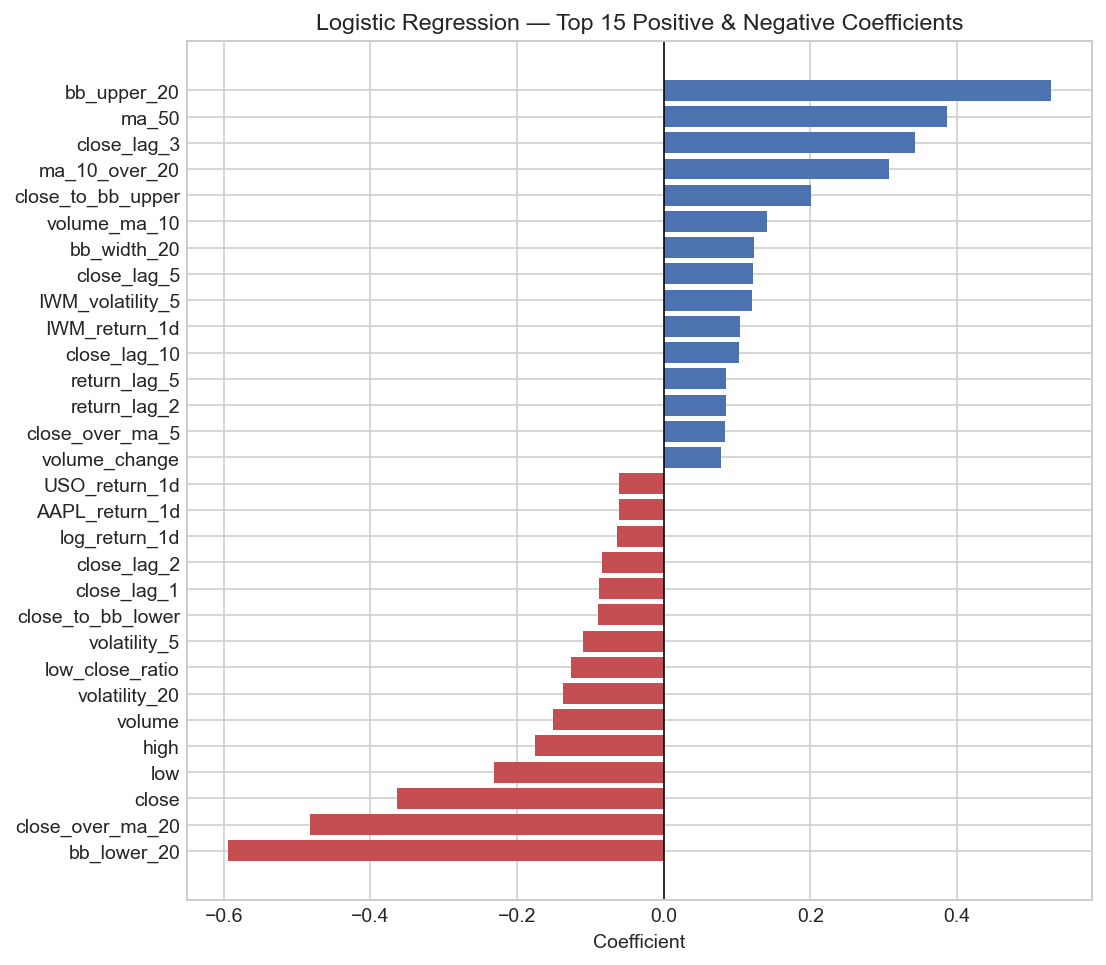

In [ ]:
if "TABLES_DIR" not in dir():
    TABLES_DIR = (PROJECT_ROOT if "PROJECT_ROOT" in dir() else Path.cwd().parent) / "results" / "tables"
if "FIGURES_DIR" not in dir():
    FIGURES_DIR = (PROJECT_ROOT if "PROJECT_ROOT" in dir() else Path.cwd().parent) / "results" / "figures" / "model_comparison"
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)

coef_df  = pd.read_csv(TABLES_DIR / "logistic_coefficients.csv")
feat_col = "feature" if "feature" in coef_df.columns else coef_df.columns[0]
coef_col = "coefficient" if "coefficient" in coef_df.columns else coef_df.columns[1]
coef_df  = coef_df.sort_values(coef_col)

top_n   = 15
plot_df = pd.concat([coef_df.head(top_n), coef_df.tail(top_n)])

fig, ax = plt.subplots(figsize=(8, 7))
colors  = ["#c44e52" if v < 0 else "#4c72b0" for v in plot_df[coef_col]]
ax.barh(plot_df[feat_col], plot_df[coef_col], color=colors)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Coefficient")
ax.set_title(f"Logistic Regression — Top {top_n} Positive & Negative Coefficients")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "lr_coefficients.svg", bbox_inches="tight")
plt.show()


### XGBoost Feature Importance (Top 20)

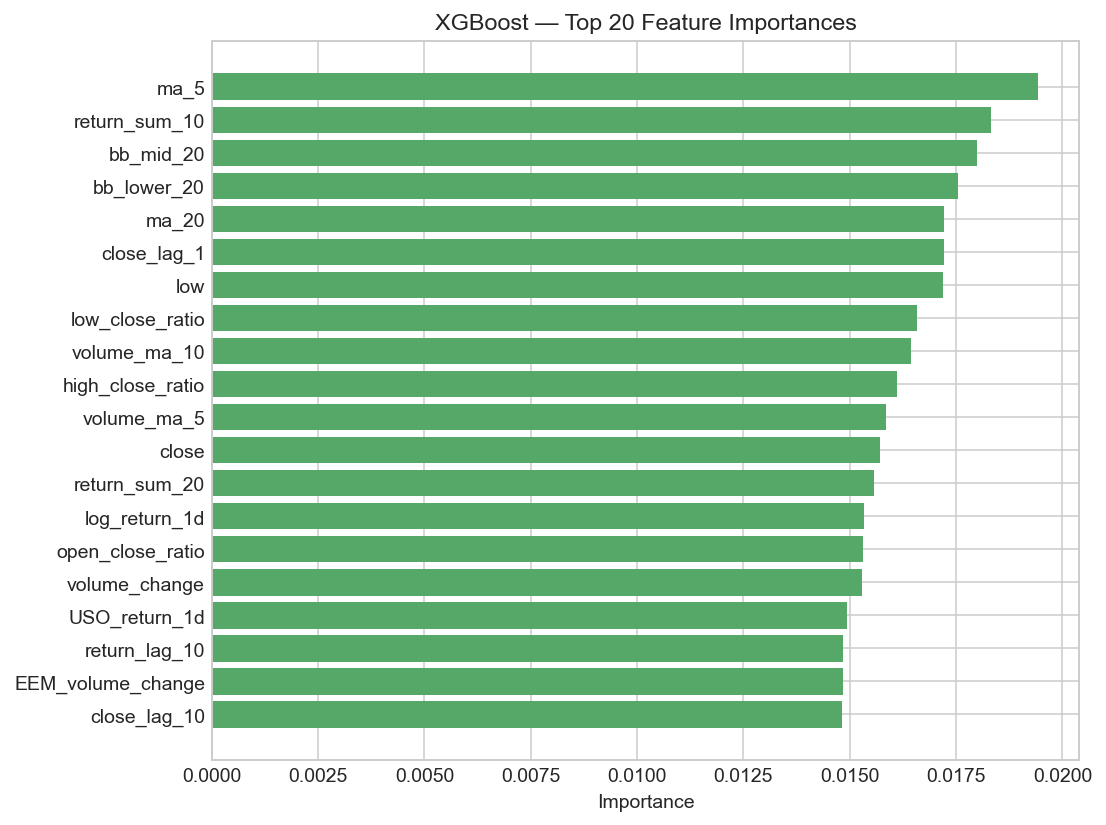

In [ ]:
if "TABLES_DIR" not in dir():
    TABLES_DIR = (PROJECT_ROOT if "PROJECT_ROOT" in dir() else Path.cwd().parent) / "results" / "tables"
if "FIGURES_DIR" not in dir():
    FIGURES_DIR = (PROJECT_ROOT if "PROJECT_ROOT" in dir() else Path.cwd().parent) / "results" / "figures" / "model_comparison"
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)

imp_df    = pd.read_csv(TABLES_DIR / "tree_feature_importance.csv")
feat_col2 = "feature" if "feature" in imp_df.columns else imp_df.columns[0]
imp_col   = "importance" if "importance" in imp_df.columns else imp_df.columns[1]
imp_df    = imp_df.nlargest(20, imp_col)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(imp_df[feat_col2], imp_df[imp_col], color="#55a868")
ax.invert_yaxis()
ax.set_xlabel("Importance")
ax.set_title("XGBoost — Top 20 Feature Importances")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "xgboost_feature_importance.svg", bbox_inches="tight")
plt.show()


## Consolidated Performance Chart

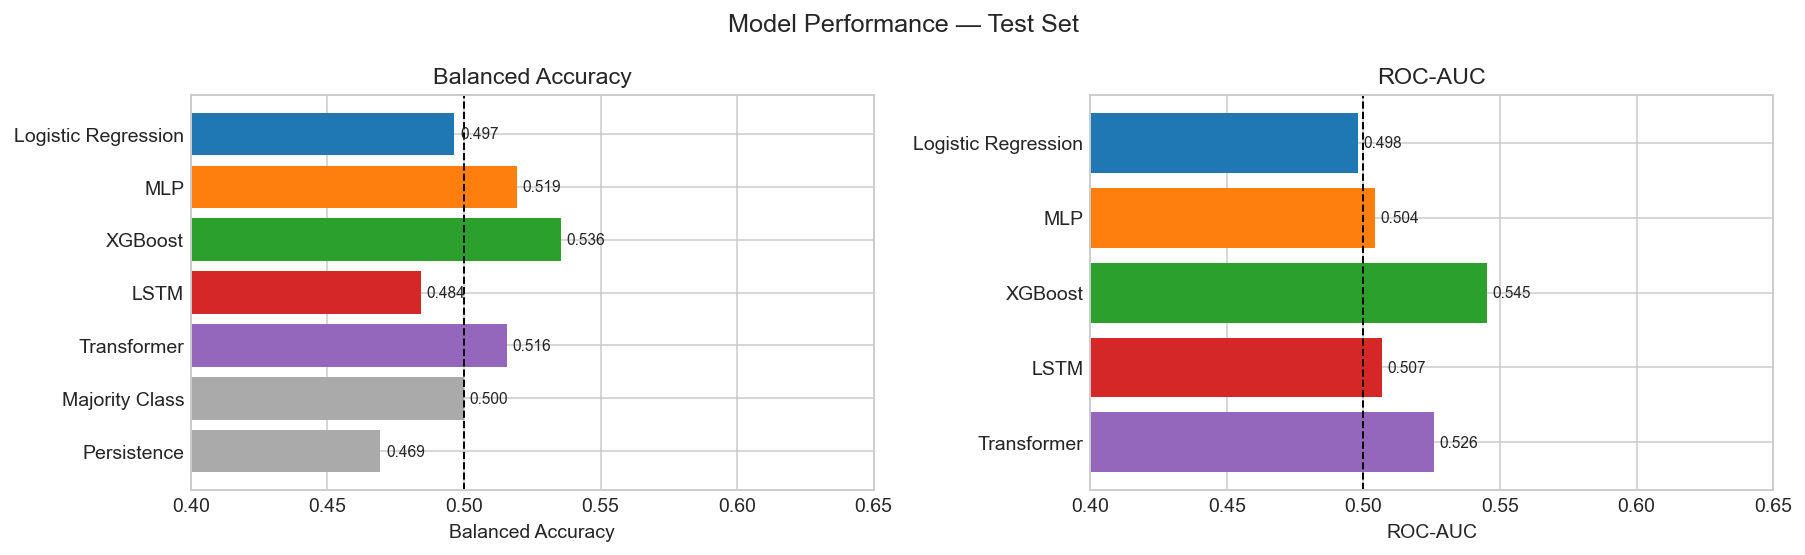

In [ ]:
if "TABLES_DIR" not in dir():
    TABLES_DIR = (PROJECT_ROOT if "PROJECT_ROOT" in dir() else Path.cwd().parent) / "results" / "tables"
if "FIGURES_DIR" not in dir():
    FIGURES_DIR = (PROJECT_ROOT if "PROJECT_ROOT" in dir() else Path.cwd().parent) / "results" / "figures" / "model_comparison"
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
if "eval_results" not in dir():
    eval_results = pd.read_csv(TABLES_DIR / "evaluation_summary.csv").set_index("model")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
metrics_plot     = ["balanced_accuracy", "roc_auc"]
titles           = ["Balanced Accuracy", "ROC-AUC"]
model_order_full = ["Logistic Regression", "MLP", "XGBoost",
                    "LSTM", "Transformer", "Majority Class", "Persistence"]
baseline_names   = {"Majority Class", "Persistence"}

for ax, metric, title in zip(axes, metrics_plot, titles):
    vals = eval_results.loc[model_order_full, metric].values
    clrs = ["#aaaaaa" if m in baseline_names else sns.color_palette("tab10")[i]
            for i, m in enumerate(model_order_full)]
    bars = ax.barh(model_order_full[::-1], vals[::-1], color=clrs[::-1])
    ax.axvline(0.5, color="k", lw=1, ls="--")
    ax.set_xlabel(title)
    ax.set_title(title)
    ax.set_xlim(0.4, 0.65)
    for bar, val in zip(bars, vals[::-1]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=8)

fig.suptitle("Model Performance — Test Set", fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "model_comparison_bar.svg", bbox_inches="tight")
plt.show()
